<div class="hero">
  <div class="eyebrow">MODEL A · PROOF OF CONCEPT · ACCELEROMETER + GPS</div>
  <h1>Estimasi Kekasaran Jalan Relatif</h1>
  <p class="hero-copy">Notebook end-to-end untuk mengubah getaran smartphone menjadi skor kekasaran relatif per segmen 20 meter—mulai dari audit data, pemrosesan sinyal, feature engineering, speed correction, unsupervised modeling, sampai peta kandidat hotspot.</p>
  <div class="hero-tags">
    <span>Data: satu sesi sepeda</span><span>Target: skor relatif 0–100</span><span>Output: Rendah · Sedang · Tinggi</span>
  </div>
</div>

> **Keputusan ilmiah utama:** dataset ini tidak memiliki label kondisi jalan maupun IRI referensi. Karena itu, notebook tidak mengklaim IRI absolut atau diagnosis kerusakan. Outputnya adalah **ranking kekasaran relatif dalam sesi ini** dan **kandidat hotspot getaran** yang perlu diverifikasi di lapangan.


In [ ]:
# Colab-ready dependency bootstrap. Di Colab standar, mayoritas paket sudah tersedia.
import importlib.util
import subprocess
import sys

REQUIRED = {
    "pandas": "pandas>=2.1",
    "scipy": "scipy>=1.11",
    "sklearn": "scikit-learn>=1.4",
    "matplotlib": "matplotlib>=3.8",
    "seaborn": "seaborn>=0.13",
    "folium": "folium>=0.15",
}
missing = [package for module, package in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Semua dependency utama tersedia.")


Semua dependency utama tersedia.


In [ ]:
from __future__ import annotations

import io
import json
import math
import platform
import random
import re
import warnings
import zipfile
from pathlib import Path

import folium
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from IPython.display import HTML, Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.signal import butter, find_peaks, sosfiltfilt, welch
from scipy.stats import kurtosis
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Accessible, content-first visual system.
COLORS = {
    "primary": "#15803D",
    "secondary": "#22C55E",
    "accent": "#D97706",
    "danger": "#DC2626",
    "blue": "#2563EB",
    "ink": "#163020",
    "muted": "#64748B",
    "paper": "#F8FCF9",
    "grid": "#DDE8E0",
}
CLASS_COLORS = {"Rendah": "#15803D", "Sedang": "#D97706", "Tinggi": "#DC2626"}
CLASS_MARKERS = {"Rendah": "o", "Sedang": "s", "Tinggi": "^"}
ROUGHNESS_CMAP = LinearSegmentedColormap.from_list(
    "roughness", [COLORS["primary"], "#F4C95D", COLORS["danger"]]
)

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "axes.edgecolor": COLORS["grid"],
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.color": COLORS["grid"],
    "font.family": "DejaVu Sans",
    "text.color": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"],
})

STYLE = """
<style>
  :root { --green:#15803D; --amber:#D97706; --red:#DC2626; --ink:#163020; --muted:#64748B; }
  .hero { padding:28px 30px; border:1px solid #BBF7D0; border-left:7px solid var(--green);
          border-radius:16px; background:linear-gradient(135deg,#F0FDF4 0%,#FFFFFF 75%); margin:8px 0 18px; }
  .eyebrow { color:var(--green); font-size:12px; font-weight:800; letter-spacing:.12em; }
  .hero h1 { color:#14532D; margin:7px 0 8px; font-size:34px; line-height:1.15; }
  .hero-copy { color:#334155; font-size:16px; line-height:1.65; max-width:980px; }
  .hero-tags { display:flex; flex-wrap:wrap; gap:8px; margin-top:14px; }
  .hero-tags span { background:#DCFCE7; color:#14532D; border:1px solid #BBF7D0; padding:6px 10px;
                    border-radius:999px; font-size:12px; font-weight:700; }
  .metric-grid { display:grid; grid-template-columns:repeat(auto-fit,minmax(165px,1fr)); gap:10px; margin:12px 0 18px; }
  .metric { background:#fff; border:1px solid #DDE8E0; border-radius:12px; padding:14px 16px; min-height:86px; }
  .metric .label { color:#64748B; text-transform:uppercase; letter-spacing:.06em; font-size:10px; font-weight:800; }
  .metric .value { color:#14532D; font-size:24px; font-weight:800; margin-top:5px; }
  .metric .note { color:#64748B; font-size:11px; margin-top:2px; }
  .callout { padding:14px 16px; border-radius:10px; margin:12px 0; line-height:1.55; }
  .callout.info { background:#EFF6FF; border-left:5px solid #2563EB; }
  .callout.warn { background:#FFFBEB; border-left:5px solid #D97706; }
  .callout.success { background:#F0FDF4; border-left:5px solid #15803D; }
  .callout.danger { background:#FEF2F2; border-left:5px solid #DC2626; }
  .small-note { color:#64748B; font-size:12px; line-height:1.5; }
  table.dataframe { border-collapse:collapse !important; font-size:12px !important; }
  table.dataframe th { background:#EAF8EF !important; color:#14532D !important; font-weight:800 !important; }
  table.dataframe td, table.dataframe th { padding:7px 9px !important; border:1px solid #E2E8F0 !important; }
  h2, h3 { color:#14532D; }
</style>
"""
display(HTML(STYLE))
print(f"Python {platform.python_version()} | pandas {pd.__version__} | SciPy {scipy.__version__} | scikit-learn {sklearn.__version__}")


Python 3.13.15 | pandas 2.2.3 | SciPy 1.16.3 | scikit-learn 1.6.1


## 1 · Tujuan, pertanyaan, dan batas klaim

Notebook menjawab empat pertanyaan:

1. Apakah data sensor cukup bersih dan sinkron untuk dianalisis?
2. Bagaimana mengisolasi getaran dinamis saat orientasi smartphone berubah?
3. Segmen mana yang relatif lebih kasar setelah pengaruh kecepatan dikurangi?
4. Seberapa stabil struktur tiga kelompok kekasaran yang ditemukan tanpa label?

**Yang dapat dihasilkan:** score relatif 0–100, kelas `Rendah/Sedang/Tinggi`, serta kandidat hotspot.  
**Yang belum dapat dihasilkan:** IRI dalam m/km, jenis kerusakan (pothole/retak/speed bump), atau generalisasi ke truk.


In [ ]:
# -------------------------------
# KONFIGURASI EKSPERIMEN
# -------------------------------
FS_TARGET_HZ = 50.0
FILTER_CUTOFF_HZ = 0.5
FILTER_ORDER = 4
SEGMENT_LENGTH_M = 20.0
MIN_SEGMENT_COVERAGE_M = 18.0
MIN_SPEED_KMH = 5.0
MAX_GPS_TOLERANCE_S = 1.5
MAX_MEDIAN_GPS_ACCURACY_M = 10.0
MIN_SAMPLES_PER_SEGMENT = 50
MAX_MOVING_SAMPLE_GAP_S = 0.25

PATH_CANDIDATES = [
    Path("/content/Data Getaran.zip"),
    Path("/home/rhendy/Downloads/Data Getaran.zip"),
    Path("Data Getaran.zip"),
]
DATA_PATH = next((p for p in PATH_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("ZIP belum ditemukan. Silakan upload Data Getaran.zip ...")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("Tidak ada file yang diunggah.")
        DATA_PATH = Path(next(iter(uploaded)))
    except ImportError as exc:
        raise FileNotFoundError(
            "Data Getaran.zip tidak ditemukan. Ubah PATH_CANDIDATES atau jalankan di Colab untuk upload."
        ) from exc

print("Data source:", DATA_PATH)


Data source: /content/Data Getaran.zip


In [ ]:
REQUIRED_FILES = {
    "imu.csv", "gps.csv", "orientation.csv", "markers.csv",
    "metadata.txt", "quality_report.json", "session_info.json",
}
REQUIRED_COLUMNS = {
    "imu.csv": {"session_id", "sensor_timestamp_ns", "wall_time_ms", "sensor_type", "x", "y", "z", "accuracy"},
    "gps.csv": {"session_id", "elapsed_realtime_ns", "wall_time_ms", "latitude", "longitude", "speed_mps", "accuracy_m"},
    "orientation.csv": {"session_id", "sensor_timestamp_ns", "quat_x", "quat_y", "quat_z", "quat_w", "azimuth_deg", "pitch_deg", "roll_deg"},
    "markers.csv": {"session_id", "elapsed_realtime_ns", "wall_time_ms", "label", "latitude", "longitude"},
}

with zipfile.ZipFile(DATA_PATH) as zf:
    archive_files = set(zf.namelist())
    missing_files = REQUIRED_FILES - archive_files
    assert not missing_files, f"File wajib hilang dari ZIP: {sorted(missing_files)}"

    imu = pd.read_csv(zf.open("imu.csv"))
    gps = pd.read_csv(zf.open("gps.csv"))
    orientation = pd.read_csv(zf.open("orientation.csv"))
    markers = pd.read_csv(zf.open("markers.csv"))
    metadata_text = zf.read("metadata.txt").decode("utf-8")
    quality_report = json.loads(zf.read("quality_report.json"))
    session_info = json.loads(zf.read("session_info.json"))

for name, frame in {"imu.csv": imu, "gps.csv": gps, "orientation.csv": orientation, "markers.csv": markers}.items():
    absent = REQUIRED_COLUMNS[name] - set(frame.columns)
    assert not absent, f"Kolom wajib hilang dari {name}: {sorted(absent)}"

metadata = {}
for line in metadata_text.splitlines():
    if "=" in line:
        key, value = line.split("=", 1)
        metadata[key.strip()] = value.strip()

numeric_imu = ["sensor_timestamp_ns", "wall_time_ms", "x", "y", "z", "accuracy"]
numeric_gps = [c for c in gps.columns if c not in {"session_id", "provider"}]
numeric_orientation = [c for c in orientation.columns if c != "session_id"]
for col in numeric_imu:
    imu[col] = pd.to_numeric(imu[col], errors="coerce")
for col in numeric_gps:
    gps[col] = pd.to_numeric(gps[col], errors="coerce")
for col in numeric_orientation:
    orientation[col] = pd.to_numeric(orientation[col], errors="coerce")

T0_NS = int(min(imu["sensor_timestamp_ns"].min(), gps["elapsed_realtime_ns"].min()))
imu["t_s"] = (imu["sensor_timestamp_ns"] - T0_NS) / 1e9
gps["t_s"] = (gps["elapsed_realtime_ns"] - T0_NS) / 1e9
orientation["t_s"] = (orientation["sensor_timestamp_ns"] - T0_NS) / 1e9

def metric_cards(items):
    cards = "".join(
        f'<div class="metric"><div class="label">{label}</div><div class="value">{value}</div><div class="note">{note}</div></div>'
        for label, value, note in items
    )
    display(HTML(f'<div class="metric-grid">{cards}</div>'))

metric_cards([
    ("Session", session_info.get("session_id", "—"), "ID perekaman"),
    ("Kendaraan", str(session_info.get("vehicle", "—")).title(), "bukan data truk"),
    ("Durasi", f'{quality_report["duration_ms"] / 1000:.1f} s', "±10,6 menit"),
    ("IMU events", f'{len(imu):,}', "semua tipe sensor"),
    ("GPS fixes", f'{len(gps):,}', "sekitar 1 Hz"),
    ("Marker label", f'{len(markers):,}', "ground truth kosong"),
])


## 2 · Audit kualitas data

Audit dilakukan sebelum transformasi apa pun. Fokusnya bukan sekadar missing value, tetapi juga keteraturan timestamp, gap, akurasi GPS, dan kesesuaian asumsi paper dengan kondisi rekaman aktual.


In [ ]:
def sensor_timing_summary(frame: pd.DataFrame, sensor_name: str) -> dict:
    t = frame["sensor_timestamp_ns"].sort_values().to_numpy(dtype=np.int64)
    dt = np.diff(t) / 1e9
    duration = (t[-1] - t[0]) / 1e9
    return {
        "sensor": sensor_name,
        "samples": len(frame),
        "duration_s": duration,
        "effective_hz": (len(frame) - 1) / duration,
        "median_dt_ms": np.median(dt) * 1000,
        "p95_dt_ms": np.quantile(dt, 0.95) * 1000,
        "max_gap_s": dt.max(),
        "duplicate_ts": pd.Series(t).duplicated().sum(),
        "missing_xyz": frame[["x", "y", "z"]].isna().sum().sum(),
    }

sensor_groups = {name: group.sort_values("sensor_timestamp_ns").copy() for name, group in imu.groupby("sensor_type")}
timing = pd.DataFrame([sensor_timing_summary(group, name) for name, group in sensor_groups.items()])

audit = pd.DataFrame([
    {"stream": "imu", "rows": len(imu), "missing_cells": int(imu.isna().sum().sum()), "duplicate_rows": int(imu.duplicated().sum()), "monotonic": bool(imu["sensor_timestamp_ns"].is_monotonic_increasing)},
    {"stream": "gps", "rows": len(gps), "missing_cells": int(gps.isna().sum().sum()), "duplicate_rows": int(gps.duplicated().sum()), "monotonic": bool(gps["elapsed_realtime_ns"].is_monotonic_increasing)},
    {"stream": "orientation", "rows": len(orientation), "missing_cells": int(orientation.isna().sum().sum()), "duplicate_rows": int(orientation.duplicated().sum()), "monotonic": bool(orientation["sensor_timestamp_ns"].is_monotonic_increasing)},
    {"stream": "markers", "rows": len(markers), "missing_cells": int(markers.isna().sum().sum()), "duplicate_rows": int(markers.duplicated().sum()), "monotonic": True if markers.empty else bool(markers["elapsed_realtime_ns"].is_monotonic_increasing)},
])

display(Markdown("**Kelengkapan dan urutan data**"))
display(audit.style.format({"rows": "{:,}", "missing_cells": "{:,}", "duplicate_rows": "{:,}"}).hide(axis="index"))
display(Markdown("**Frekuensi dan gap tiap sensor IMU**"))
display(timing.style.format({"samples": "{:,}", "duration_s": "{:.2f}", "effective_hz": "{:.2f}", "median_dt_ms": "{:.2f}", "p95_dt_ms": "{:.2f}", "max_gap_s": "{:.3f}"}).hide(axis="index"))


**Kelengkapan dan urutan data**

stream,rows,missing_cells,duplicate_rows,monotonic
imu,"89,543",0,0,False
gps,637,0,0,True
orientation,"9,824",0,0,True
markers,0,0,0,True


**Frekuensi dan gap tiap sensor IMU**

sensor,samples,duration_s,effective_hz,median_dt_ms,p95_dt_ms,max_gap_s,duplicate_ts,missing_xyz
accelerometer,"32,957",637.00,51.74,19.33,19.33,0.039,0,0
gravity,"9,824",636.95,15.42,19.33,19.33,447.072,0,0
gyroscope,"15,602",636.97,24.49,19.33,77.31,0.092,0,0
linear_acceleration,"31,160",636.98,48.92,19.33,19.33,34.683,0,0


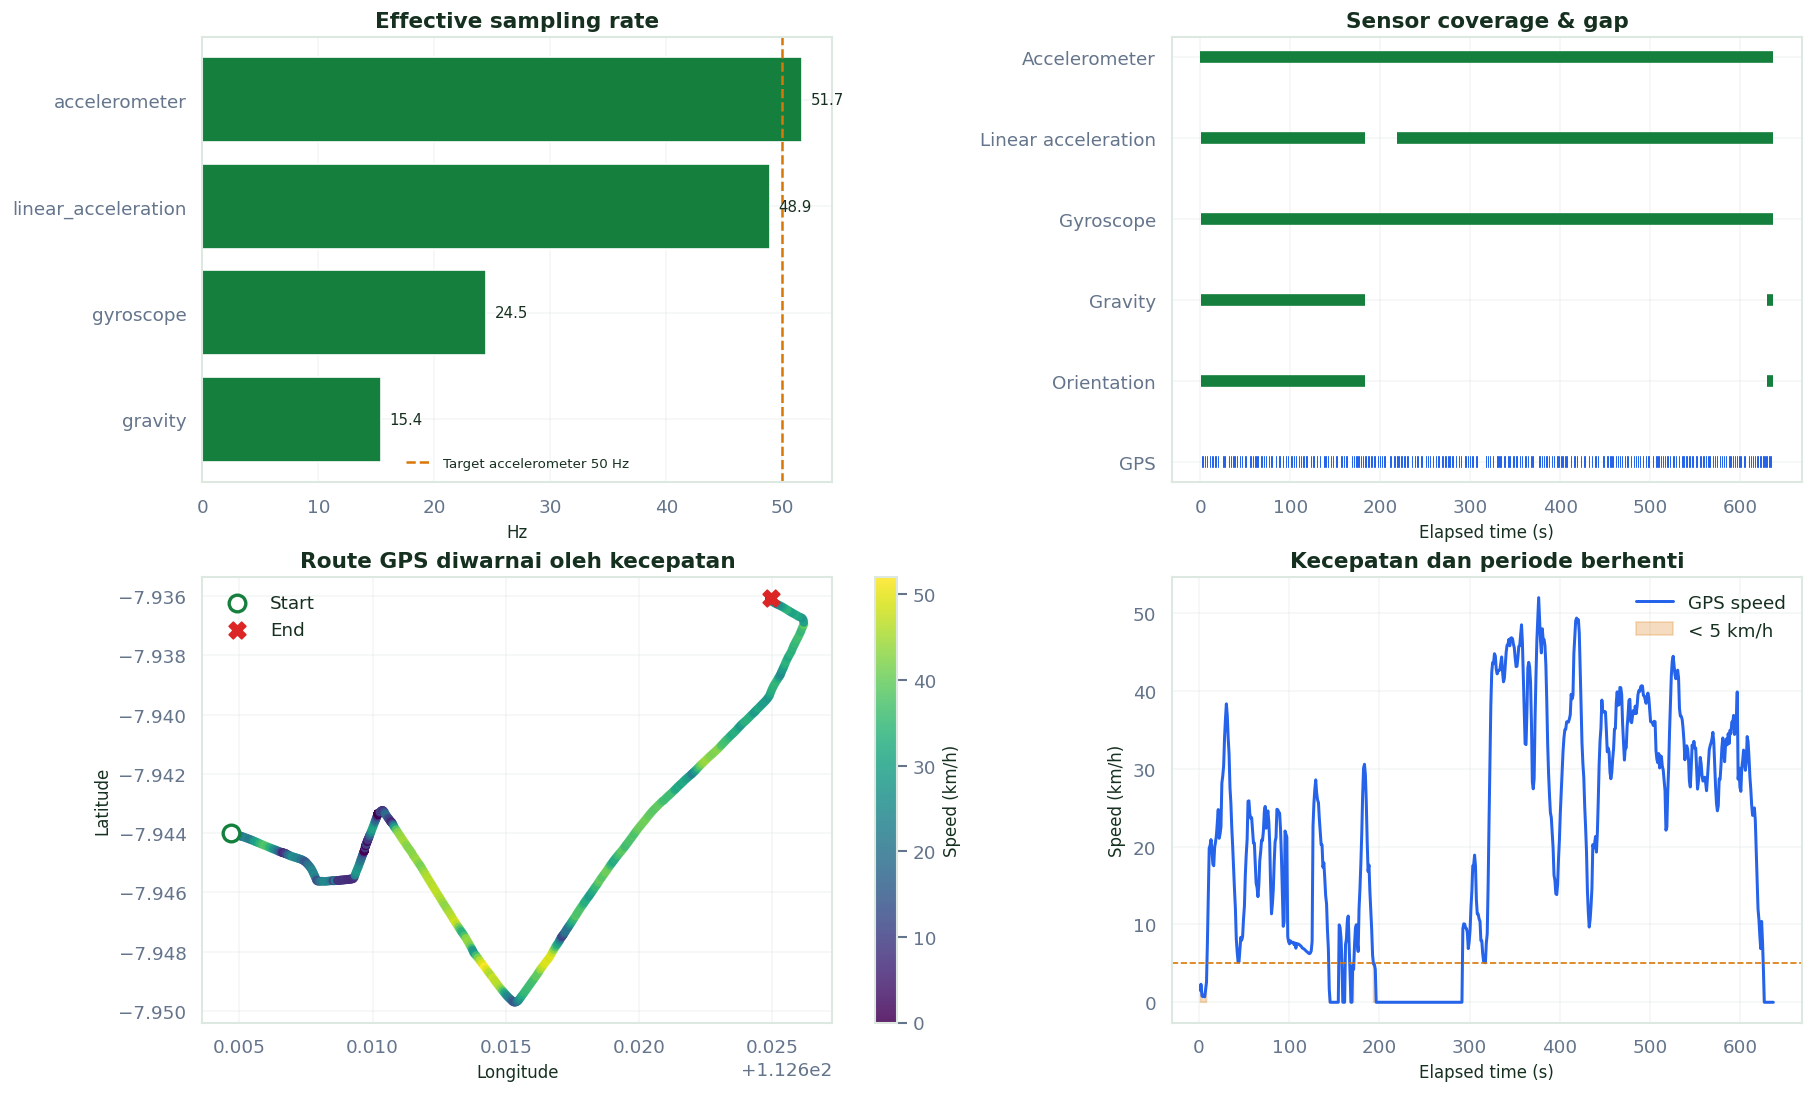

In [ ]:
def coverage_intervals(times: np.ndarray, gap_threshold_s: float = 1.0):
    times = np.sort(np.asarray(times, dtype=float))
    if len(times) == 0:
        return []
    split_at = np.where(np.diff(times) > gap_threshold_s)[0]
    starts = np.r_[0, split_at + 1]
    ends = np.r_[split_at, len(times) - 1]
    return [(times[s], times[e]) for s, e in zip(starts, ends)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

# Sampling rates
rate_plot = timing.sort_values("effective_hz")
axes[0, 0].barh(rate_plot["sensor"], rate_plot["effective_hz"], color=COLORS["primary"])
axes[0, 0].axvline(FS_TARGET_HZ, color=COLORS["accent"], linestyle="--", label="Target accelerometer 50 Hz")
for i, value in enumerate(rate_plot["effective_hz"]):
    axes[0, 0].text(value + 0.7, i, f"{value:.1f}", va="center", fontsize=9)
axes[0, 0].set(title="Effective sampling rate", xlabel="Hz", ylabel="")
axes[0, 0].legend(frameon=False, fontsize=8)

# Coverage timeline
coverage_streams = {
    "Accelerometer": sensor_groups["accelerometer"]["t_s"].to_numpy(),
    "Linear acceleration": sensor_groups["linear_acceleration"]["t_s"].to_numpy(),
    "Gyroscope": sensor_groups["gyroscope"]["t_s"].to_numpy(),
    "Gravity": sensor_groups["gravity"]["t_s"].to_numpy(),
    "Orientation": orientation["t_s"].to_numpy(),
    "GPS": gps["t_s"].to_numpy(),
}
for y, (name, times) in enumerate(coverage_streams.items()):
    for start, end in coverage_intervals(times):
        axes[0, 1].plot([start, end], [y, y], lw=7, solid_capstyle="butt", color=COLORS["blue"] if name == "GPS" else COLORS["primary"])
axes[0, 1].set_yticks(range(len(coverage_streams)), list(coverage_streams))
axes[0, 1].set(title="Sensor coverage & gap", xlabel="Elapsed time (s)", ylabel="")
axes[0, 1].invert_yaxis()

# GPS route
route_scatter = axes[1, 0].scatter(gps["longitude"], gps["latitude"], c=gps["speed_mps"] * 3.6, cmap="viridis", s=18, alpha=0.85)
axes[1, 0].scatter(gps["longitude"].iloc[0], gps["latitude"].iloc[0], marker="o", s=100, facecolor="white", edgecolor=COLORS["primary"], linewidth=2, label="Start")
axes[1, 0].scatter(gps["longitude"].iloc[-1], gps["latitude"].iloc[-1], marker="X", s=100, color=COLORS["danger"], label="End")
axes[1, 0].set(title="Route GPS diwarnai oleh kecepatan", xlabel="Longitude", ylabel="Latitude")
axes[1, 0].legend(frameon=False)
plt.colorbar(route_scatter, ax=axes[1, 0], label="Speed (km/h)")

# Speed timeline
speed_kmh = gps["speed_mps"] * 3.6
axes[1, 1].plot(gps["t_s"], speed_kmh, color=COLORS["blue"], lw=1.8, label="GPS speed")
axes[1, 1].fill_between(gps["t_s"], 0, speed_kmh, where=speed_kmh < MIN_SPEED_KMH, color=COLORS["accent"], alpha=0.25, label=f"< {MIN_SPEED_KMH:g} km/h")
axes[1, 1].axhline(MIN_SPEED_KMH, color=COLORS["accent"], linestyle="--", lw=1)
axes[1, 1].set(title="Kecepatan dan periode berhenti", xlabel="Elapsed time (s)", ylabel="Speed (km/h)")
axes[1, 1].legend(frameon=False)

plt.show()


In [ ]:
# Uji asumsi kalibrasi 5 detik pertama dari Zang et al. (2018).
acc_raw = sensor_groups["accelerometer"].sort_values("sensor_timestamp_ns").copy()
first_t = acc_raw["t_s"].iloc[0]
first5 = acc_raw.loc[acc_raw["t_s"] < first_t + 5, ["x", "y", "z"]].to_numpy()
first5_mean = first5.mean(axis=0)
first5_axis_std = first5.std(axis=0, ddof=1)
first5_norm = np.linalg.norm(first5_mean)
first5_stable = bool(np.mean(first5_axis_std) < 0.5 and abs(first5_norm - 9.80665) < 0.5)

max_gps_gap = float(np.diff(gps["elapsed_realtime_ns"].to_numpy()) .max() / 1e9)
gps_accuracy = gps["accuracy_m"]
long_stop_s = 0.0
stopped = speed_kmh < 2.0
start_idx = None
stop_runs = []
for idx, is_stopped in enumerate(stopped):
    if is_stopped and start_idx is None:
        start_idx = idx
    if start_idx is not None and (not is_stopped or idx == len(stopped) - 1):
        end_idx = idx if is_stopped and idx == len(stopped) - 1 else idx - 1
        stop_runs.append(float(gps["t_s"].iloc[end_idx] - gps["t_s"].iloc[start_idx]))
        start_idx = None
if stop_runs:
    long_stop_s = max(stop_runs)

metric_cards([
    ("Accel effective", f'{timing.loc[timing.sensor == "accelerometer", "effective_hz"].iloc[0]:.2f} Hz', "kontinu sepanjang sesi"),
    ("GPS accuracy", f'{gps_accuracy.median():.1f} m', f'P95 {gps_accuracy.quantile(.95):.1f} m'),
    ("Max GPS gap", f"{max_gps_gap:.3f} s", "aman untuk toleransi 1,5 s"),
    ("Stop terpanjang", f"{long_stop_s:.0f} s", "dikeluarkan dari model"),
    ("Orientation gap", f'{timing.loc[timing.sensor == "gravity", "max_gap_s"].iloc[0]:.0f} s', "tidak dipakai sebagai sinyal utama"),
    ("Initial calibration", "Lulus" if first5_stable else "Gagal", f"|mean| {first5_norm:.2f} m/s²"),
])

calibration_class = "success" if first5_stable else "warn"
calibration_text = (
    "Lima detik pertama cukup stabil untuk reference-vector statis."
    if first5_stable
    else "Lima detik pertama tidak stabil: variasi sumbu terlalu besar dan magnitudo mean jauh dari 1g. Karena itu notebook memakai dynamic gravity compensation, bukan proyeksi ke satu reference vector awal."
)
display(HTML(f'<div class="callout {calibration_class}"><b>Initial calibration check.</b> {calibration_text}</div>'))


## 3 · Regularisasi, dynamic gravity compensation, dan sinkronisasi GPS

Accelerometer mentah menyimpan gravitasi sekaligus gerak. Karena posisi smartphone dapat berubah, memilih sumbu Z secara langsung berisiko. Pipeline berikut:

1. menginterpolasi XYZ ke grid 50 Hz;
2. mengestimasi vektor gravitasi lokal menggunakan low-pass 0,5 Hz;
3. mengambil komponen dinamis dengan high-pass 0,5 Hz;
4. memproyeksikan komponen dinamis ke arah gravitasi lokal untuk mendapatkan **vertical vibration proxy**;
5. menyelaraskan speed, lokasi, dan akurasi GPS dengan toleransi nearest-fix 1,5 detik.

Filter Butterworth menggunakan second-order sections dan zero-phase output agar stabil secara numerik serta tidak menggeser posisi kejadian.


In [ ]:
acc_t = acc_raw["t_s"].to_numpy(dtype=float)
acc_xyz = acc_raw[["x", "y", "z"]].to_numpy(dtype=float)
grid_start = math.ceil(acc_t.min() * FS_TARGET_HZ) / FS_TARGET_HZ
grid_end = math.floor(acc_t.max() * FS_TARGET_HZ) / FS_TARGET_HZ
t_grid = np.arange(grid_start, grid_end + 0.5 / FS_TARGET_HZ, 1 / FS_TARGET_HZ)

acc_regular = np.column_stack([np.interp(t_grid, acc_t, acc_xyz[:, axis]) for axis in range(3)])
sos_low = butter(FILTER_ORDER, FILTER_CUTOFF_HZ, btype="lowpass", fs=FS_TARGET_HZ, output="sos")
sos_high = butter(FILTER_ORDER, FILTER_CUTOFF_HZ, btype="highpass", fs=FS_TARGET_HZ, output="sos")
gravity_xyz = np.column_stack([sosfiltfilt(sos_low, acc_regular[:, axis]) for axis in range(3)])
dynamic_xyz = np.column_stack([sosfiltfilt(sos_high, acc_regular[:, axis]) for axis in range(3)])

gravity_norm = np.linalg.norm(gravity_xyz, axis=1)
gravity_unit = gravity_xyz / np.clip(gravity_norm[:, None], 1e-6, None)
vertical_acc = np.sum(dynamic_xyz * gravity_unit, axis=1)
resultant_acc = np.linalg.norm(dynamic_xyz, axis=1)
vertical_jerk = np.gradient(vertical_acc, 1 / FS_TARGET_HZ)

gps_sorted = gps.sort_values("t_s").reset_index(drop=True)
gps_t = gps_sorted["t_s"].to_numpy(dtype=float)
gps_speed_mps = gps_sorted["speed_mps"].to_numpy(dtype=float)
gps_speed_kmh = gps_speed_mps * 3.6

# Primary distance follows speed integration; Haversine remains a cross-check.
gps_distance_m = cumulative_trapezoid(gps_speed_mps, gps_t, initial=0.0)

def haversine_m(lat1, lon1, lat2, lon2):
    radius = 6_371_000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * radius * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

hav_steps = haversine_m(
    gps_sorted["latitude"].to_numpy()[:-1], gps_sorted["longitude"].to_numpy()[:-1],
    gps_sorted["latitude"].to_numpy()[1:], gps_sorted["longitude"].to_numpy()[1:],
)
hav_distance_m = float(np.sum(hav_steps))

# Nearest-fix distance prevents silent extrapolation through large gaps.
right_idx = np.searchsorted(gps_t, t_grid, side="left")
right_idx = np.clip(right_idx, 0, len(gps_t) - 1)
left_idx = np.clip(right_idx - 1, 0, len(gps_t) - 1)
nearest_gap_s = np.minimum(np.abs(t_grid - gps_t[left_idx]), np.abs(t_grid - gps_t[right_idx]))

aligned = pd.DataFrame({
    "t_s": t_grid,
    "acc_x": acc_regular[:, 0],
    "acc_y": acc_regular[:, 1],
    "acc_z": acc_regular[:, 2],
    "gravity_norm": gravity_norm,
    "vertical_acc": vertical_acc,
    "resultant_acc": resultant_acc,
    "vertical_jerk": vertical_jerk,
    "speed_mps": np.interp(t_grid, gps_t, gps_speed_mps),
    "speed_kmh": np.interp(t_grid, gps_t, gps_speed_kmh),
    "distance_m": np.interp(t_grid, gps_t, gps_distance_m),
    "latitude": np.interp(t_grid, gps_t, gps_sorted["latitude"]),
    "longitude": np.interp(t_grid, gps_t, gps_sorted["longitude"]),
    "gps_accuracy_m": np.interp(t_grid, gps_t, gps_sorted["accuracy_m"]),
    "nearest_gps_gap_s": nearest_gap_s,
})
aligned["edge_valid"] = aligned["t_s"].between(aligned["t_s"].min() + 2, aligned["t_s"].max() - 2)
aligned["gps_valid"] = aligned["nearest_gps_gap_s"] <= MAX_GPS_TOLERANCE_S
aligned["moving"] = aligned["speed_kmh"] >= MIN_SPEED_KMH
aligned["analysis_valid"] = aligned["edge_valid"] & aligned["gps_valid"] & aligned["moving"]
aligned["segment_id"] = np.floor(aligned["distance_m"] / SEGMENT_LENGTH_M).astype(int)

metric_cards([
    ("Distance · speed", f"{gps_distance_m[-1] / 1000:.3f} km", "dipakai untuk segmentasi"),
    ("Distance · GPS", f"{hav_distance_m / 1000:.3f} km", "cross-check Haversine"),
    ("Selisih", f"{(hav_distance_m / gps_distance_m[-1] - 1) * 100:.1f}%", "GPS drift + metode berbeda"),
    ("Grid samples", f"{len(aligned):,}", "50 Hz regular"),
    ("Moving samples", f'{aligned["analysis_valid"].sum():,}', f'≥ {MIN_SPEED_KMH:g} km/h'),
])


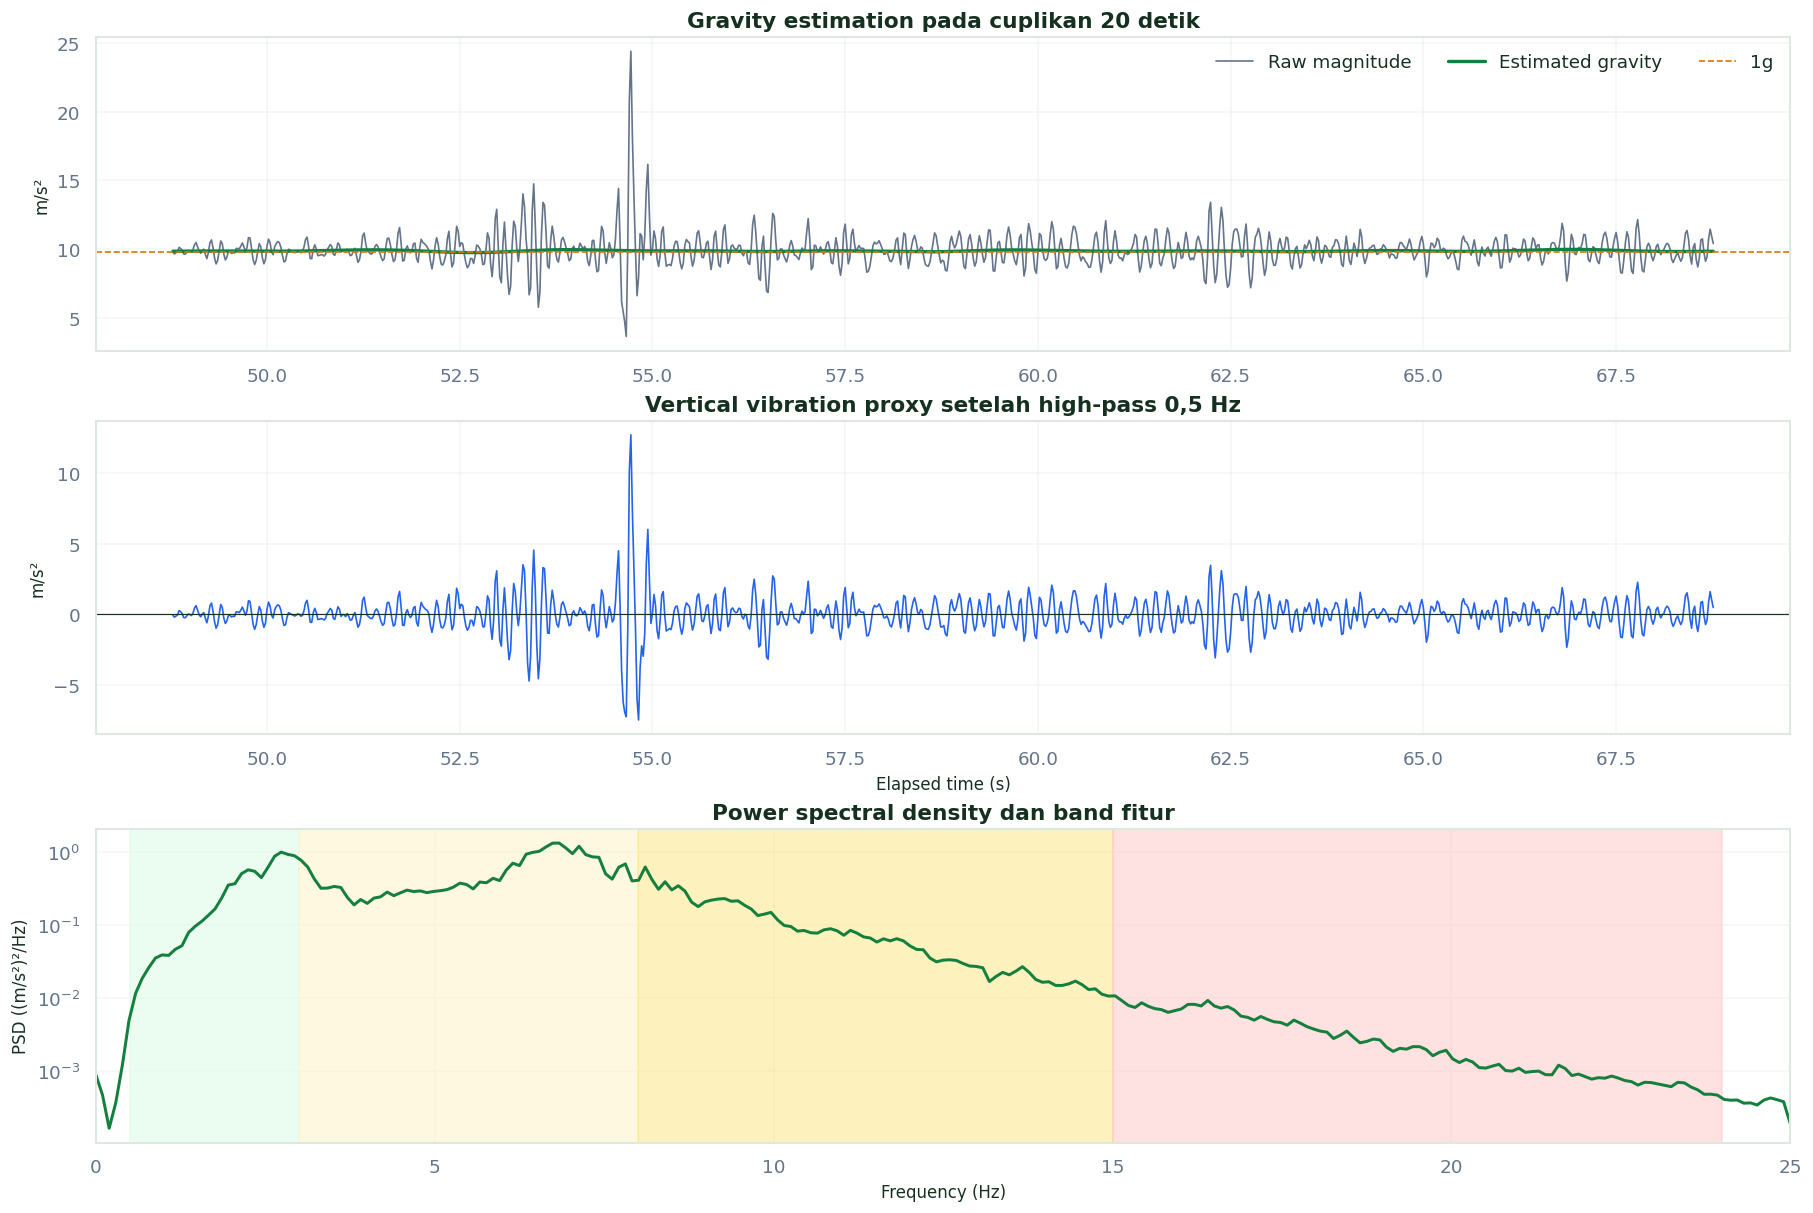

In [ ]:
# Cross-check dynamic acceleration against Android linear_acceleration where observations overlap.
lin = sensor_groups["linear_acceleration"].sort_values("t_s")
lin_t = lin["t_s"].to_numpy(dtype=float)
lin_mag = np.linalg.norm(lin[["x", "y", "z"]].to_numpy(dtype=float), axis=1)
result_at_lin = np.interp(lin_t, aligned["t_s"], aligned["resultant_acc"])
validation_r = float(np.corrcoef(lin_mag, result_at_lin)[0, 1])

moving_window = aligned.query("analysis_valid").copy()
preview_start = float(moving_window["t_s"].quantile(0.08))
preview = aligned[aligned["t_s"].between(preview_start, preview_start + 20)]

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False, constrained_layout=True)
axes[0].plot(preview["t_s"], np.linalg.norm(preview[["acc_x", "acc_y", "acc_z"]], axis=1), color=COLORS["muted"], lw=1, label="Raw magnitude")
axes[0].plot(preview["t_s"], preview["gravity_norm"], color=COLORS["primary"], lw=2, label="Estimated gravity")
axes[0].axhline(9.80665, color=COLORS["accent"], ls="--", lw=1, label="1g")
axes[0].set(title="Gravity estimation pada cuplikan 20 detik", ylabel="m/s²")
axes[0].legend(frameon=False, ncol=3)

axes[1].plot(preview["t_s"], preview["vertical_acc"], color=COLORS["blue"], lw=1)
axes[1].axhline(0, color=COLORS["ink"], lw=0.7)
axes[1].set(title="Vertical vibration proxy setelah high-pass 0,5 Hz", xlabel="Elapsed time (s)", ylabel="m/s²")

freq, psd = welch(
    moving_window["vertical_acc"].to_numpy(dtype=float),
    fs=FS_TARGET_HZ,
    nperseg=512,
    noverlap=256,
    scaling="density",
)
axes[2].semilogy(freq, psd, color=COLORS["primary"], lw=1.8)
for lo, hi, color in [(0.5, 3, "#DCFCE7"), (3, 8, "#FEF3C7"), (8, 15, "#FDE68A"), (15, 24, "#FECACA")]:
    axes[2].axvspan(lo, hi, color=color, alpha=0.55)
axes[2].set(xlim=(0, 25), title="Power spectral density dan band fitur", xlabel="Frequency (Hz)", ylabel="PSD ((m/s²)²/Hz)")
plt.show()

display(HTML(f'<div class="callout info"><b>Cross-check linear acceleration.</b> Korelasi magnitudo dynamic acceleration dengan sensor Android linear_acceleration pada area overlap adalah <b>r = {validation_r:.3f}</b>. Stream Android tidak dijadikan sumber utama karena memiliki gap panjang.</div>'))


## 4 · Segmentasi spasial dan feature engineering

Unit analisis mengikuti studi rujukan: **20 meter**. Segmentasi berbasis jarak lebih relevan daripada window waktu karena keputusan akhirnya dipakai untuk memetakan lokasi jalan. Setiap segmen diberi quality flag; hanya segmen penuh, cukup padat, kontinu, bergerak, dan memiliki GPS layak yang masuk training.


In [ ]:
def band_power(freq: np.ndarray, power: np.ndarray, low: float, high: float) -> float:
    mask = (freq >= low) & (freq < high)
    return float(trapezoid(power[mask], freq[mask])) if mask.sum() >= 2 else 0.0

def robust_mad(values: np.ndarray) -> float:
    median = np.median(values)
    return float(np.median(np.abs(values - median)))

def extract_segment_features(segment: pd.DataFrame) -> dict:
    seg = segment.loc[segment["analysis_valid"]].sort_values("t_s").copy()
    a = seg["vertical_acc"].to_numpy(dtype=float)
    jerk = seg["vertical_jerk"].to_numpy(dtype=float)
    abs_a = np.abs(a)
    times = seg["t_s"].to_numpy(dtype=float)
    distances = seg["distance_m"].to_numpy(dtype=float)
    coverage_m = float(distances.max() - distances.min()) if len(distances) else 0.0
    max_gap_s = float(np.diff(times).max()) if len(times) > 1 else np.inf

    prominence = max(3.0 * robust_mad(abs_a), 0.25)
    peaks, _ = find_peaks(abs_a, prominence=prominence, distance=max(1, int(0.10 * FS_TARGET_HZ)))
    nperseg = min(128, len(a))
    f, pxx = welch(a, fs=FS_TARGET_HZ, nperseg=nperseg, noverlap=nperseg // 2, scaling="density")

    reasons = []
    if coverage_m < MIN_SEGMENT_COVERAGE_M:
        reasons.append("coverage<18m")
    if len(seg) < MIN_SAMPLES_PER_SEGMENT:
        reasons.append("samples<50")
    if max_gap_s > MAX_MOVING_SAMPLE_GAP_S:
        reasons.append("discontinuous")
    if float(seg["gps_accuracy_m"].median()) > MAX_MEDIAN_GPS_ACCURACY_M:
        reasons.append("gps>10m")

    segment_distance = max(coverage_m, 1e-6)
    return {
        "segment_id": int(segment["segment_id"].iloc[0]),
        "segment_start_m": int(segment["segment_id"].iloc[0] * SEGMENT_LENGTH_M),
        "segment_end_m": int((segment["segment_id"].iloc[0] + 1) * SEGMENT_LENGTH_M),
        "start_time_s": float(times.min()),
        "end_time_s": float(times.max()),
        "latitude": float(seg["latitude"].median()),
        "longitude": float(seg["longitude"].median()),
        "mean_speed_kmh": float(seg["speed_kmh"].mean()),
        "speed_std_kmh": float(seg["speed_kmh"].std(ddof=1)),
        "median_gps_accuracy_m": float(seg["gps_accuracy_m"].median()),
        "n_samples": int(len(seg)),
        "distance_coverage_m": coverage_m,
        "max_sample_gap_s": max_gap_s,
        "rms_vertical": float(np.sqrt(np.mean(a ** 2))),
        "std_vertical": float(np.std(a, ddof=1)),
        "mean_abs": float(np.mean(abs_a)),
        "p95_abs": float(np.quantile(abs_a, 0.95)),
        "p99_abs": float(np.quantile(abs_a, 0.99)),
        "peak_to_peak": float(np.ptp(a)),
        "crest_factor": float(abs_a.max() / max(np.sqrt(np.mean(a ** 2)), 1e-9)),
        "kurtosis": float(kurtosis(a, fisher=True, bias=False)),
        "vdv_per_m": float((np.sum(a ** 4) / FS_TARGET_HZ / segment_distance) ** 0.25),
        "jerk_rms": float(np.sqrt(np.mean(jerk ** 2))),
        "peak_density_per_m": float(len(peaks) / segment_distance),
        "psd_0_5_3hz": band_power(f, pxx, 0.5, 3.0),
        "psd_3_8hz": band_power(f, pxx, 3.0, 8.0),
        "psd_8_15hz": band_power(f, pxx, 8.0, 15.0),
        "psd_15_24hz": band_power(f, pxx, 15.0, 24.0),
        "psd_3_15hz": band_power(f, pxx, 3.0, 15.0),
        "data_quality_flag": "OK" if not reasons else " | ".join(reasons),
        "valid_segment": not reasons,
    }

feature_rows = []
for segment_id, segment in aligned.groupby("segment_id", sort=True):
    moving_part = segment.loc[segment["analysis_valid"]]
    if len(moving_part) >= 2:
        feature_rows.append(extract_segment_features(segment))

features = pd.DataFrame(feature_rows).sort_values("segment_id").reset_index(drop=True)
valid_features = features.loc[features["valid_segment"]].copy().reset_index(drop=True)

quality_counts = features["data_quality_flag"].value_counts().rename_axis("quality_flag").reset_index(name="segments")
metric_cards([
    ("Segmen terdeteksi", f"{len(features):,}", "termasuk quality flag"),
    ("Segmen valid", f"{len(valid_features):,}", "masuk training"),
    ("Coverage median", f'{valid_features["distance_coverage_m"].median():.1f} m', "target 20 m"),
    ("Samples median", f'{valid_features["n_samples"].median():.0f}', "per segmen"),
    ("Speed median", f'{valid_features["mean_speed_kmh"].median():.1f} km/h', "reference speed"),
])
display(quality_counts.style.hide(axis="index"))


quality_flag,segments
OK,182
discontinuous,3
coverage<18m,2


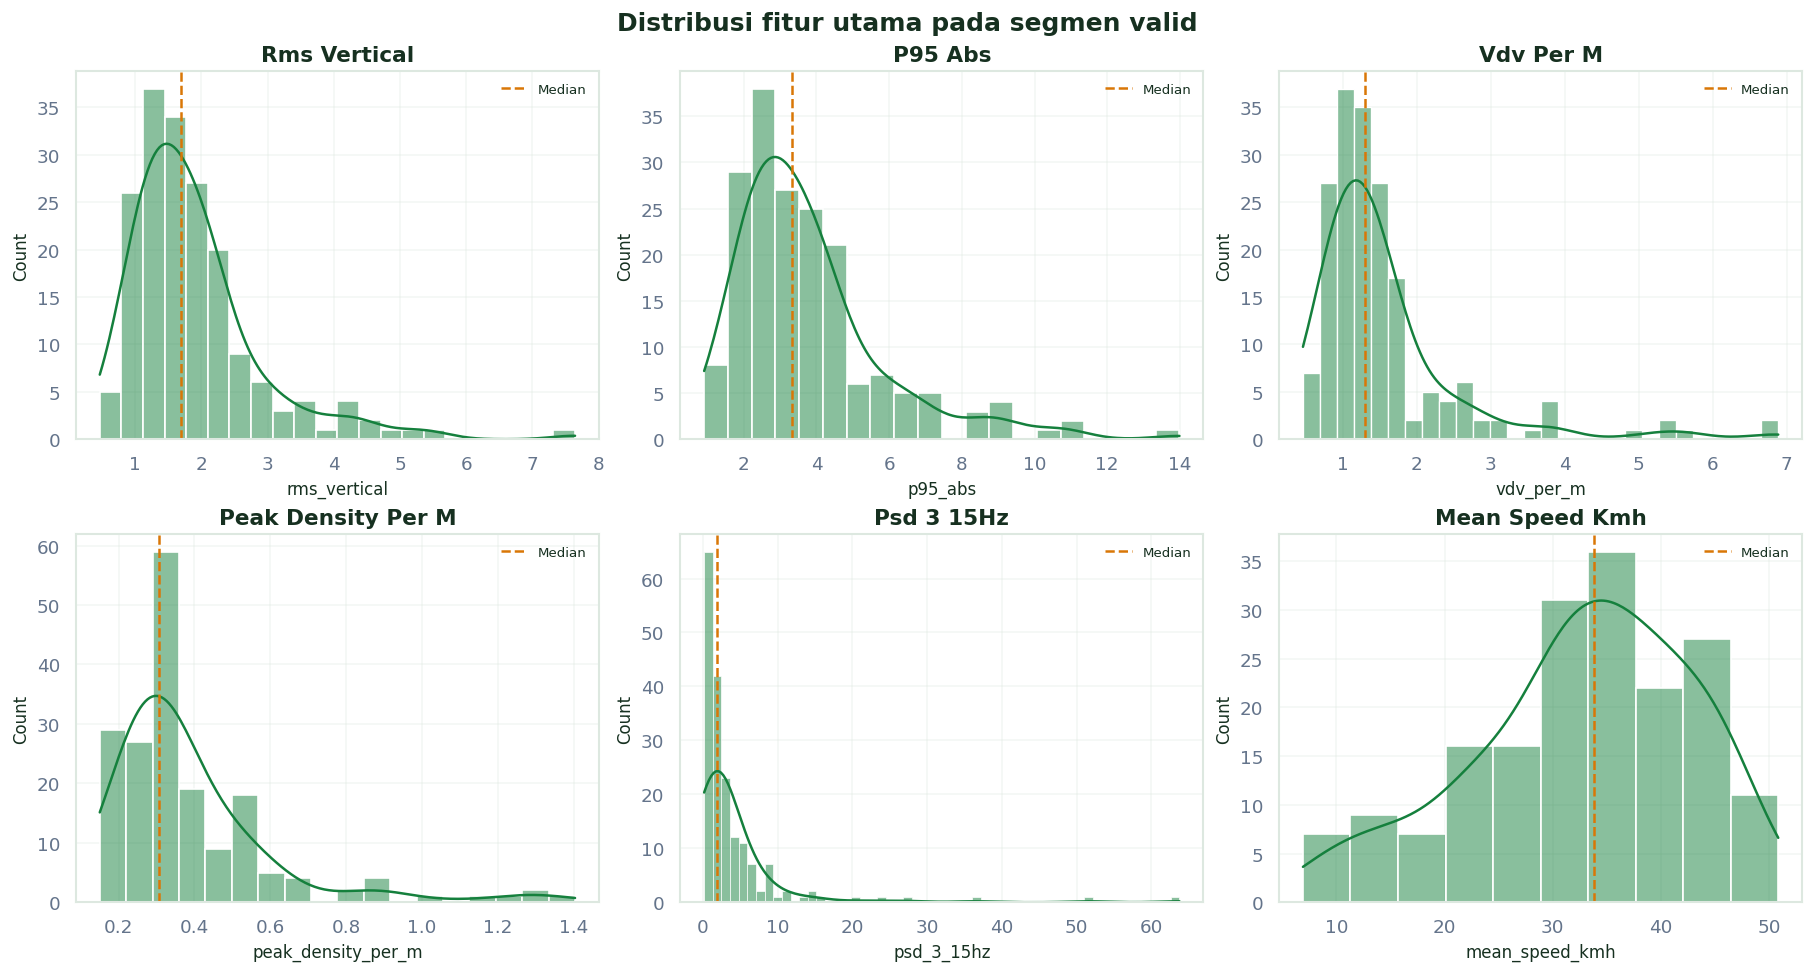

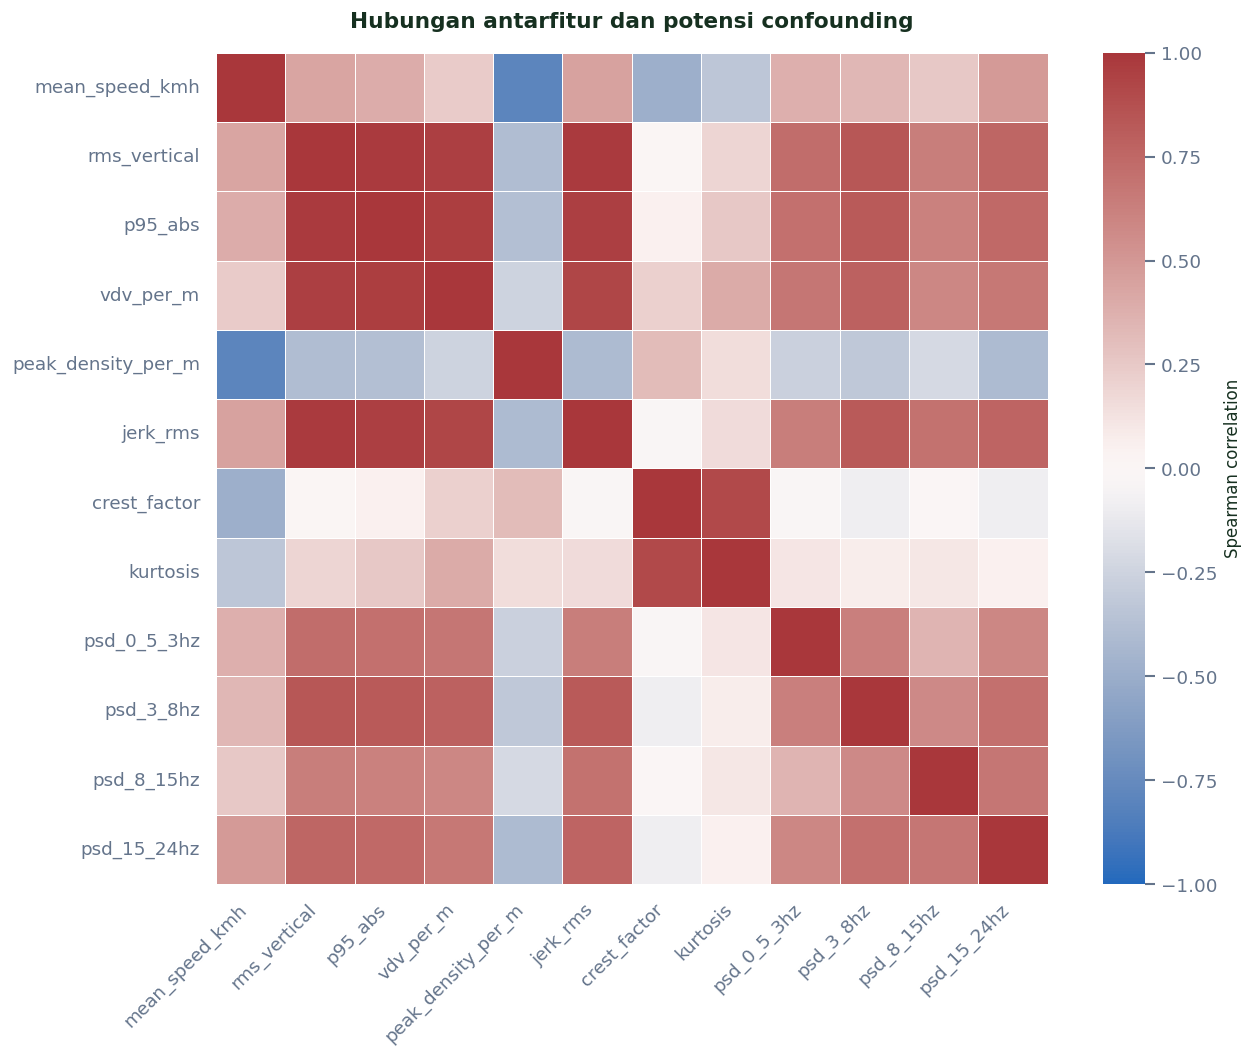

In [ ]:
feature_view = ["rms_vertical", "p95_abs", "vdv_per_m", "peak_density_per_m", "psd_3_15hz", "mean_speed_kmh"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for ax, column in zip(axes.flat, feature_view):
    sns.histplot(valid_features[column], kde=True, ax=ax, color=COLORS["primary"], edgecolor="white")
    ax.axvline(valid_features[column].median(), color=COLORS["accent"], ls="--", lw=1.5, label="Median")
    ax.set_title(column.replace("_", " ").title())
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Distribusi fitur utama pada segmen valid", fontsize=15, fontweight="bold")
plt.show()

corr_columns = [
    "mean_speed_kmh", "rms_vertical", "p95_abs", "vdv_per_m", "peak_density_per_m",
    "jerk_rms", "crest_factor", "kurtosis", "psd_0_5_3hz", "psd_3_8hz", "psd_8_15hz", "psd_15_24hz",
]
corr = valid_features[corr_columns].corr(method="spearman")
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.4, cbar_kws={"label": "Spearman correlation"})
plt.title("Hubungan antarfitur dan potensi confounding", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


## 5 · Speed correction dan relative roughness score

Getaran meningkat saat kendaraan bergerak lebih cepat, bahkan pada permukaan yang sama. Karena tidak ada repeated pass pada kecepatan berbeda, koreksi ini bersifat **data-driven sensitivity adjustment**, bukan kalibrasi universal.

Untuk setiap fitur intensitas positif, hubungan `log(feature) ~ log(speed)` di-fit dengan Huber regression. Nilai lalu dinormalisasi ke median speed sesi. Koreksi hanya diterapkan bila hubungan empiris feature–speed positif; koefisien negatif atau hubungan nonpositif diperlakukan sebagai nol agar koreksi tidak membalik hubungan fisik dasar.

`Peak density` tetap ditampilkan sebagai diagnostic feature, tetapi dikeluarkan dari scoring/model karena pada single pass ini nilainya sangat terkait dengan lamanya waktu di dalam segmen 20 m—bukan hanya kondisi permukaan.


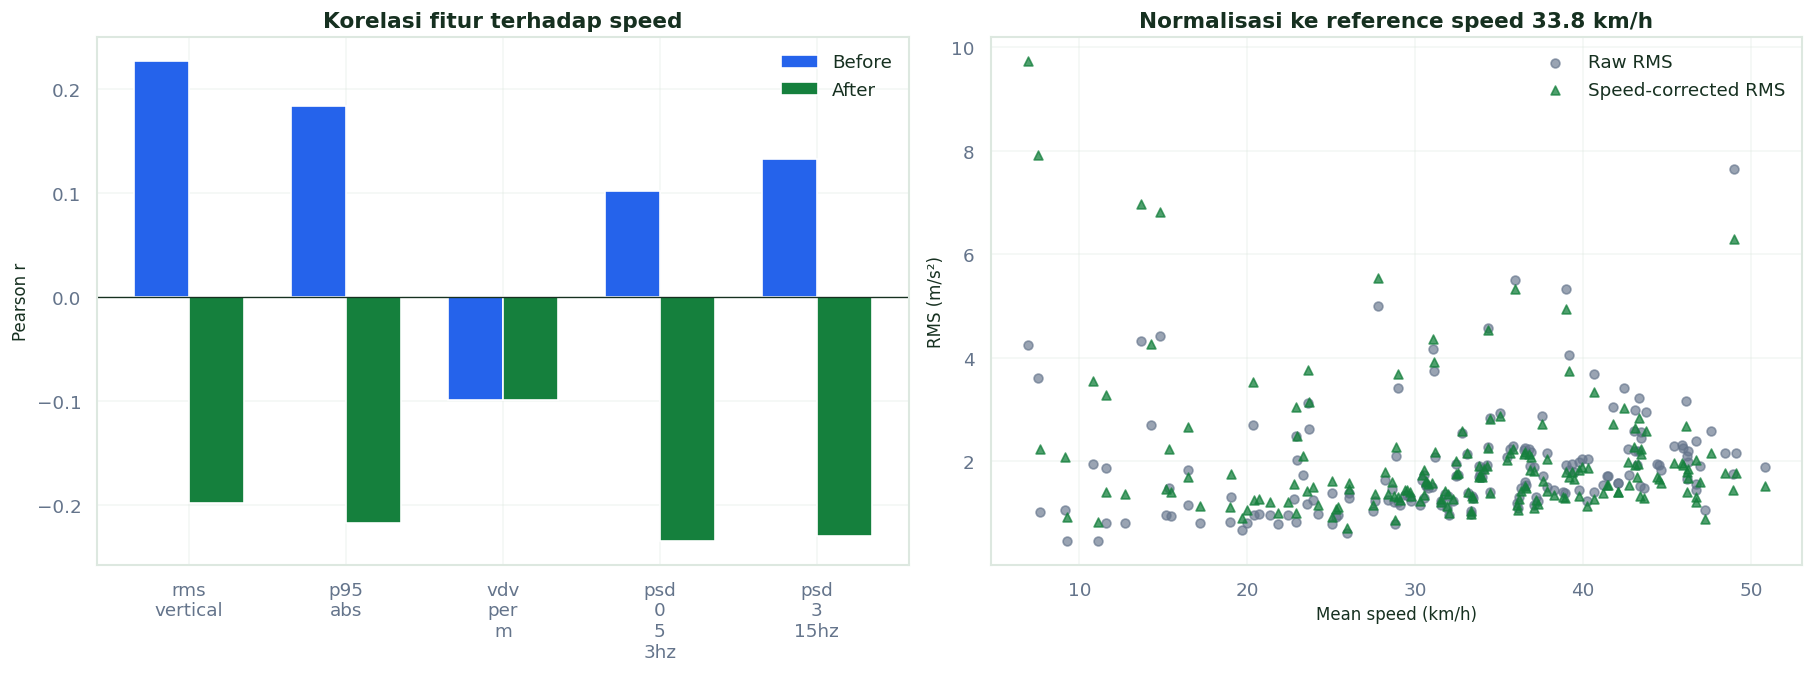

feature,gamma_raw,gamma_used,r_before,r_after
rms_vertical,0.524,0.524,0.226,-0.198
p95_abs,0.507,0.507,0.183,-0.218
vdv_per_m,0.211,0.000,-0.100,-0.100
psd_0_5_3hz,1.352,1.352,0.102,-0.235
psd_3_15hz,1.135,1.135,0.132,-0.230


In [ ]:
# Peak density remains a diagnostic only: on this single pass it is strongly
# coupled to time spent inside a fixed-distance segment. The model therefore
# uses continuous vibration-energy features that are safer to speed-correct.
CORE_FEATURES = ["rms_vertical", "p95_abs", "vdv_per_m", "psd_0_5_3hz", "psd_3_15hz"]
REFERENCE_SPEED_KMH = float(valid_features["mean_speed_kmh"].median())
speed_models = {}
speed_diagnostics = []

for feature in CORE_FEATURES:
    x_speed = np.log(valid_features[["mean_speed_kmh"]].to_numpy())
    epsilon = max(float(valid_features[feature].quantile(0.01)) * 0.01, 1e-9)
    y_feature = np.log(valid_features[feature].to_numpy() + epsilon)
    model = HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=1000).fit(x_speed, y_feature)
    gamma_raw = float(model.coef_[0])
    r_before = float(valid_features[[feature, "mean_speed_kmh"]].corr().iloc[0, 1])
    gamma_used = max(0.0, gamma_raw) if r_before > 0 else 0.0
    corrected_name = f"{feature}_corr"
    valid_features[corrected_name] = valid_features[feature] * (REFERENCE_SPEED_KMH / valid_features["mean_speed_kmh"]) ** gamma_used
    speed_models[feature] = model
    speed_diagnostics.append({
        "feature": feature,
        "gamma_raw": gamma_raw,
        "gamma_used": gamma_used,
        "r_before": r_before,
        "r_after": valid_features[[corrected_name, "mean_speed_kmh"]].corr().iloc[0, 1],
    })

speed_diagnostics = pd.DataFrame(speed_diagnostics)
corrected_features = [f"{feature}_corr" for feature in CORE_FEATURES]

# Equal-weight, robust session-relative score: median of per-feature percentile ranks.
percentile_matrix = valid_features[corrected_features].rank(pct=True, method="average")
valid_features["relative_roughness_score"] = (100 * percentile_matrix.median(axis=1)).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
x = np.arange(len(speed_diagnostics))
width = 0.35
axes[0].bar(x - width / 2, speed_diagnostics["r_before"], width, color=COLORS["blue"], label="Before")
axes[0].bar(x + width / 2, speed_diagnostics["r_after"], width, color=COLORS["primary"], label="After")
axes[0].axhline(0, color=COLORS["ink"], lw=0.8)
axes[0].set_xticks(x, [f.replace("_", "\n") for f in CORE_FEATURES])
axes[0].set(title="Korelasi fitur terhadap speed", ylabel="Pearson r")
axes[0].legend(frameon=False)

axes[1].scatter(valid_features["mean_speed_kmh"], valid_features["rms_vertical"], s=28, alpha=0.65, color=COLORS["muted"], label="Raw RMS")
axes[1].scatter(valid_features["mean_speed_kmh"], valid_features["rms_vertical_corr"], s=28, alpha=0.75, color=COLORS["primary"], marker="^", label="Speed-corrected RMS")
axes[1].set(title=f"Normalisasi ke reference speed {REFERENCE_SPEED_KMH:.1f} km/h", xlabel="Mean speed (km/h)", ylabel="RMS (m/s²)")
axes[1].legend(frameon=False)
plt.show()

display(speed_diagnostics.style.format({"gamma_raw": "{:.3f}", "gamma_used": "{:.3f}", "r_before": "{:.3f}", "r_after": "{:.3f}"}).hide(axis="index"))


## 6 · Modeling: tiga kelompok kekasaran relatif

K-Means dilatih pada **percentile rank** lima fitur inti yang sudah dikoreksi, kemudian di-RobustScale. Rank transform membatasi dominasi satu extreme segment pada fitur yang heavy-tailed, sehingga cluster merepresentasikan level relatif—bukan sekadar memisahkan satu outlier. Jumlah cluster dikunci tiga untuk kebutuhan operasional yang mudah dijelaskan. Nama cluster tidak diambil langsung dari ID K-Means; cluster diurutkan berdasarkan median score lalu diberi nama `Rendah`, `Sedang`, dan `Tinggi`.

Karena target eksternal tidak ada, **accuracy, F1, MAE, atau R² tidak valid**. Evaluasi menggunakan cohesion/separation dan stability terhadap bootstrap resampling.


In [ ]:
scaler = RobustScaler(quantile_range=(25.0, 75.0))
X = scaler.fit_transform(percentile_matrix.to_numpy(dtype=float))

kmeans = KMeans(n_clusters=3, n_init=50, random_state=SEED, algorithm="lloyd")
raw_cluster = kmeans.fit_predict(X)
valid_features["raw_cluster"] = raw_cluster

cluster_order = (
    valid_features.groupby("raw_cluster")["relative_roughness_score"]
    .median().sort_values().index.tolist()
)
ordered_names = ["Rendah", "Sedang", "Tinggi"]
cluster_name_map = {cluster: name for cluster, name in zip(cluster_order, ordered_names)}
valid_features["roughness_class"] = valid_features["raw_cluster"].map(cluster_name_map)
class_counts_model = valid_features["roughness_class"].value_counts().reindex(ordered_names)

hotspot_threshold = float(valid_features["relative_roughness_score"].quantile(0.90))
valid_features["hotspot_flag"] = (
    (valid_features["roughness_class"] == "Tinggi")
    & (valid_features["relative_roughness_score"] >= hotspot_threshold)
)

# Internal validation
model_metrics = {
    "Silhouette ↑": silhouette_score(X, raw_cluster),
    "Davies–Bouldin ↓": davies_bouldin_score(X, raw_cluster),
    "Calinski–Harabasz ↑": calinski_harabasz_score(X, raw_cluster),
}

# Bootstrap stability: refit on resampled segments, predict all original segments, compare to reference partition.
rng = np.random.default_rng(SEED)
bootstrap_ari = []
for iteration in range(100):
    sample_idx = rng.choice(len(X), size=len(X), replace=True)
    boot_model = KMeans(n_clusters=3, n_init=20, random_state=SEED + iteration + 1)
    boot_model.fit(X[sample_idx])
    bootstrap_ari.append(adjusted_rand_score(raw_cluster, boot_model.predict(X)))
bootstrap_ari = np.asarray(bootstrap_ari)
model_metrics["Bootstrap ARI median ↑"] = float(np.median(bootstrap_ari))
model_metrics["Bootstrap ARI P05 ↑"] = float(np.quantile(bootstrap_ari, 0.05))

# k=2..5 diagnostics for transparency, while k=3 remains the operational choice.
k_diagnostics = []
for k in range(2, 6):
    labels_k = KMeans(n_clusters=k, n_init=30, random_state=SEED).fit_predict(X)
    k_diagnostics.append({
        "k": k,
        "silhouette": silhouette_score(X, labels_k),
        "davies_bouldin": davies_bouldin_score(X, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X, labels_k),
    })
k_diagnostics = pd.DataFrame(k_diagnostics)

# PCA is for explanation only; model uses the full corrected feature matrix.
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)
valid_features["pca_1"] = X_pca[:, 0]
valid_features["pca_2"] = X_pca[:, 1]

metric_cards([
    ("Silhouette", f'{model_metrics["Silhouette ↑"]:.3f}', "lebih tinggi lebih terpisah"),
    ("Davies–Bouldin", f'{model_metrics["Davies–Bouldin ↓"]:.3f}', "lebih rendah lebih baik"),
    ("Bootstrap ARI", f'{model_metrics["Bootstrap ARI median ↑"]:.3f}', "median 100 resamples"),
    ("Min class size", f"{class_counts_model.min():.0f}", f"{class_counts_model.min() / len(valid_features) * 100:.1f}% segmen"),
    ("PCA explained", f"{pca.explained_variance_ratio_.sum() * 100:.1f}%", "khusus plot 2D"),
    ("Hotspot threshold", f"{hotspot_threshold:.1f}", "P90 + kelas Tinggi"),
])


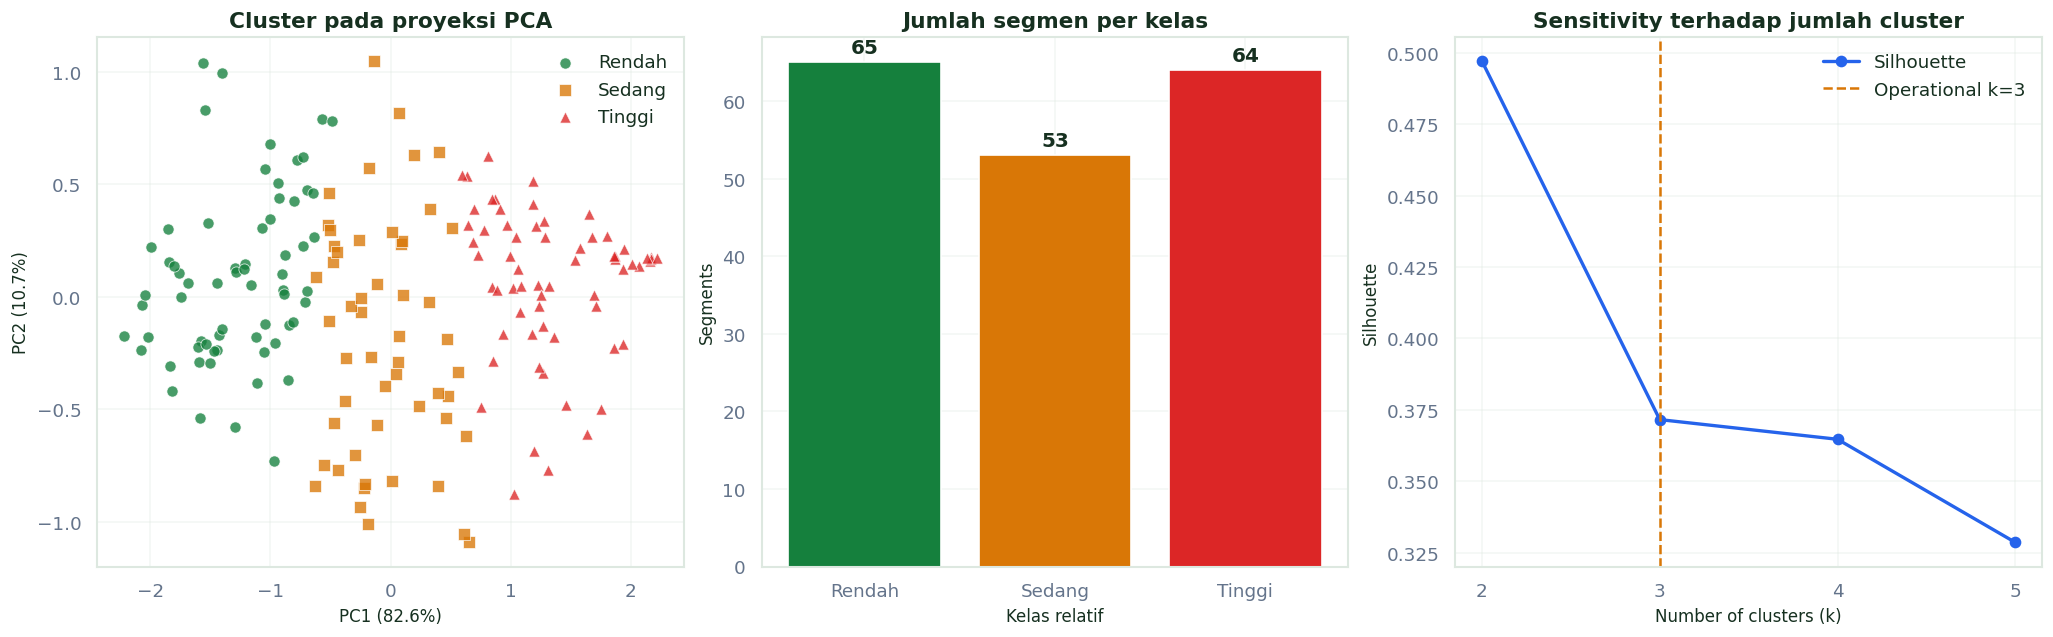

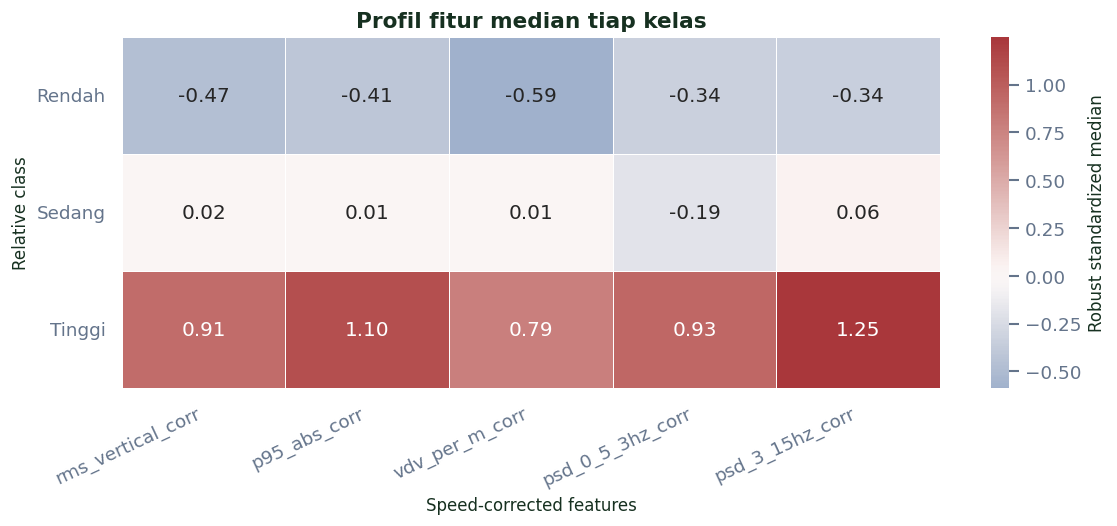

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), constrained_layout=True)

# PCA cluster map with redundant marker shapes for accessibility.
for cls in ordered_names:
    subset = valid_features[valid_features["roughness_class"] == cls]
    axes[0].scatter(subset["pca_1"], subset["pca_2"], s=45, alpha=0.78, c=CLASS_COLORS[cls], marker=CLASS_MARKERS[cls], edgecolor="white", linewidth=0.5, label=cls)
axes[0].set(title="Cluster pada proyeksi PCA", xlabel=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)", ylabel=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
axes[0].legend(frameon=False)

class_counts = valid_features["roughness_class"].value_counts().reindex(ordered_names)
bars = axes[1].bar(ordered_names, class_counts, color=[CLASS_COLORS[c] for c in ordered_names])
axes[1].bar_label(bars, padding=3, fontweight="bold")
axes[1].set(title="Jumlah segmen per kelas", xlabel="Kelas relatif", ylabel="Segments")

axes[2].plot(k_diagnostics["k"], k_diagnostics["silhouette"], marker="o", color=COLORS["blue"], lw=2, label="Silhouette")
axes[2].axvline(3, color=COLORS["accent"], ls="--", label="Operational k=3")
axes[2].set_xticks(k_diagnostics["k"])
axes[2].set(title="Sensitivity terhadap jumlah cluster", xlabel="Number of clusters (k)", ylabel="Silhouette")
axes[2].legend(frameon=False)
plt.show()

centroid_profile = (
    valid_features.groupby("roughness_class", observed=True)[corrected_features]
    .median().reindex(ordered_names)
)
centroid_profile_z = (centroid_profile - valid_features[corrected_features].median()) / valid_features[corrected_features].apply(lambda s: s.quantile(.75) - s.quantile(.25))
plt.figure(figsize=(11, 3.8))
sns.heatmap(centroid_profile_z, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.6, cbar_kws={"label": "Robust standardized median"})
plt.title("Profil fitur median tiap kelas")
plt.xlabel("Speed-corrected features")
plt.ylabel("Relative class")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.show()


## 7 · Hasil akhir dan kandidat hotspot

Score 0–100 adalah percentile-based composite **dalam sesi ini**. Nilai 80 berarti segmen tersebut lebih intens daripada mayoritas segmen lain pada perjalanan yang sama—bukan berarti IRI 80 atau kerusakan 80%.


In [ ]:
# Merge model outputs back to all extracted segments; invalid segments remain visible with their quality flag.
model_columns = [
    "segment_id", *corrected_features, "relative_roughness_score", "roughness_class",
    "hotspot_flag", "raw_cluster", "pca_1", "pca_2",
]
segment_results = features.merge(valid_features[model_columns], on="segment_id", how="left")

output_columns = [
    "segment_id", "segment_start_m", "segment_end_m", "start_time_s", "end_time_s",
    "latitude", "longitude", "mean_speed_kmh", "median_gps_accuracy_m", "n_samples",
    "distance_coverage_m", "rms_vertical", "p95_abs", "vdv_per_m", "peak_density_per_m",
    "psd_3_15hz", "relative_roughness_score", "roughness_class", "hotspot_flag", "data_quality_flag",
]
final_table = segment_results[output_columns].copy()

valid_results = final_table.dropna(subset=["relative_roughness_score"]).copy()
hotspot_table = (
    valid_results.loc[valid_results["hotspot_flag"]]
    .sort_values("relative_roughness_score", ascending=False)
)
top10 = valid_results.sort_values("relative_roughness_score", ascending=False).head(10)

high_share = float((valid_results["roughness_class"] == "Tinggi").mean() * 100)
hotspot_share = float(valid_results["hotspot_flag"].mean() * 100)
top_row = top10.iloc[0]
metric_cards([
    ("Valid result", f"{len(valid_results):,}", "segmen terklasifikasi"),
    ("Kelas Tinggi", f"{high_share:.1f}%", "dari segmen valid"),
    ("Hotspot", f"{len(hotspot_table):,}", f"{hotspot_share:.1f}% segmen"),
    ("Score tertinggi", f'{top_row["relative_roughness_score"]:.1f}', f'{top_row["segment_start_m"]:.0f}–{top_row["segment_end_m"]:.0f} m'),
    ("Koordinat top", f'{top_row["latitude"]:.5f}', f'lon {top_row["longitude"]:.5f}'),
])

display(Markdown("### Top 10 segmen berdasarkan relative roughness score"))
top_display = top10[[
    "segment_id", "segment_start_m", "segment_end_m", "relative_roughness_score",
    "roughness_class", "hotspot_flag", "mean_speed_kmh", "latitude", "longitude",
]]
display(top_display.style.format({
    "relative_roughness_score": "{:.1f}", "mean_speed_kmh": "{:.1f}",
    "latitude": "{:.6f}", "longitude": "{:.6f}",
}).background_gradient(subset=["relative_roughness_score"], cmap=ROUGHNESS_CMAP).hide(axis="index"))


### Top 10 segmen berdasarkan relative roughness score

segment_id,segment_start_m,segment_end_m,relative_roughness_score,roughness_class,hotspot_flag,mean_speed_kmh,latitude,longitude
26,520,540,100.0,Tinggi,True,6.9,-7.945556,112.609103
24,480,500,98.9,Tinggi,True,13.7,-7.945598,112.608678
25,500,520,98.9,Tinggi,True,7.5,-7.945582,112.608864
23,460,480,98.4,Tinggi,True,14.8,-7.945606,112.608535
95,1900,1920,97.8,Tinggi,True,49.0,-7.948234,112.616609
99,1980,2000,97.3,Tinggi,True,27.8,-7.947653,112.617004
133,2660,2680,96.7,Tinggi,True,36.0,-7.942810,112.621030
142,2840,2860,96.2,Tinggi,True,39.0,-7.941726,112.622295
137,2740,2760,95.1,Tinggi,True,31.1,-7.942340,112.621575
135,2700,2720,95.1,Tinggi,True,34.4,-7.942575,112.621308


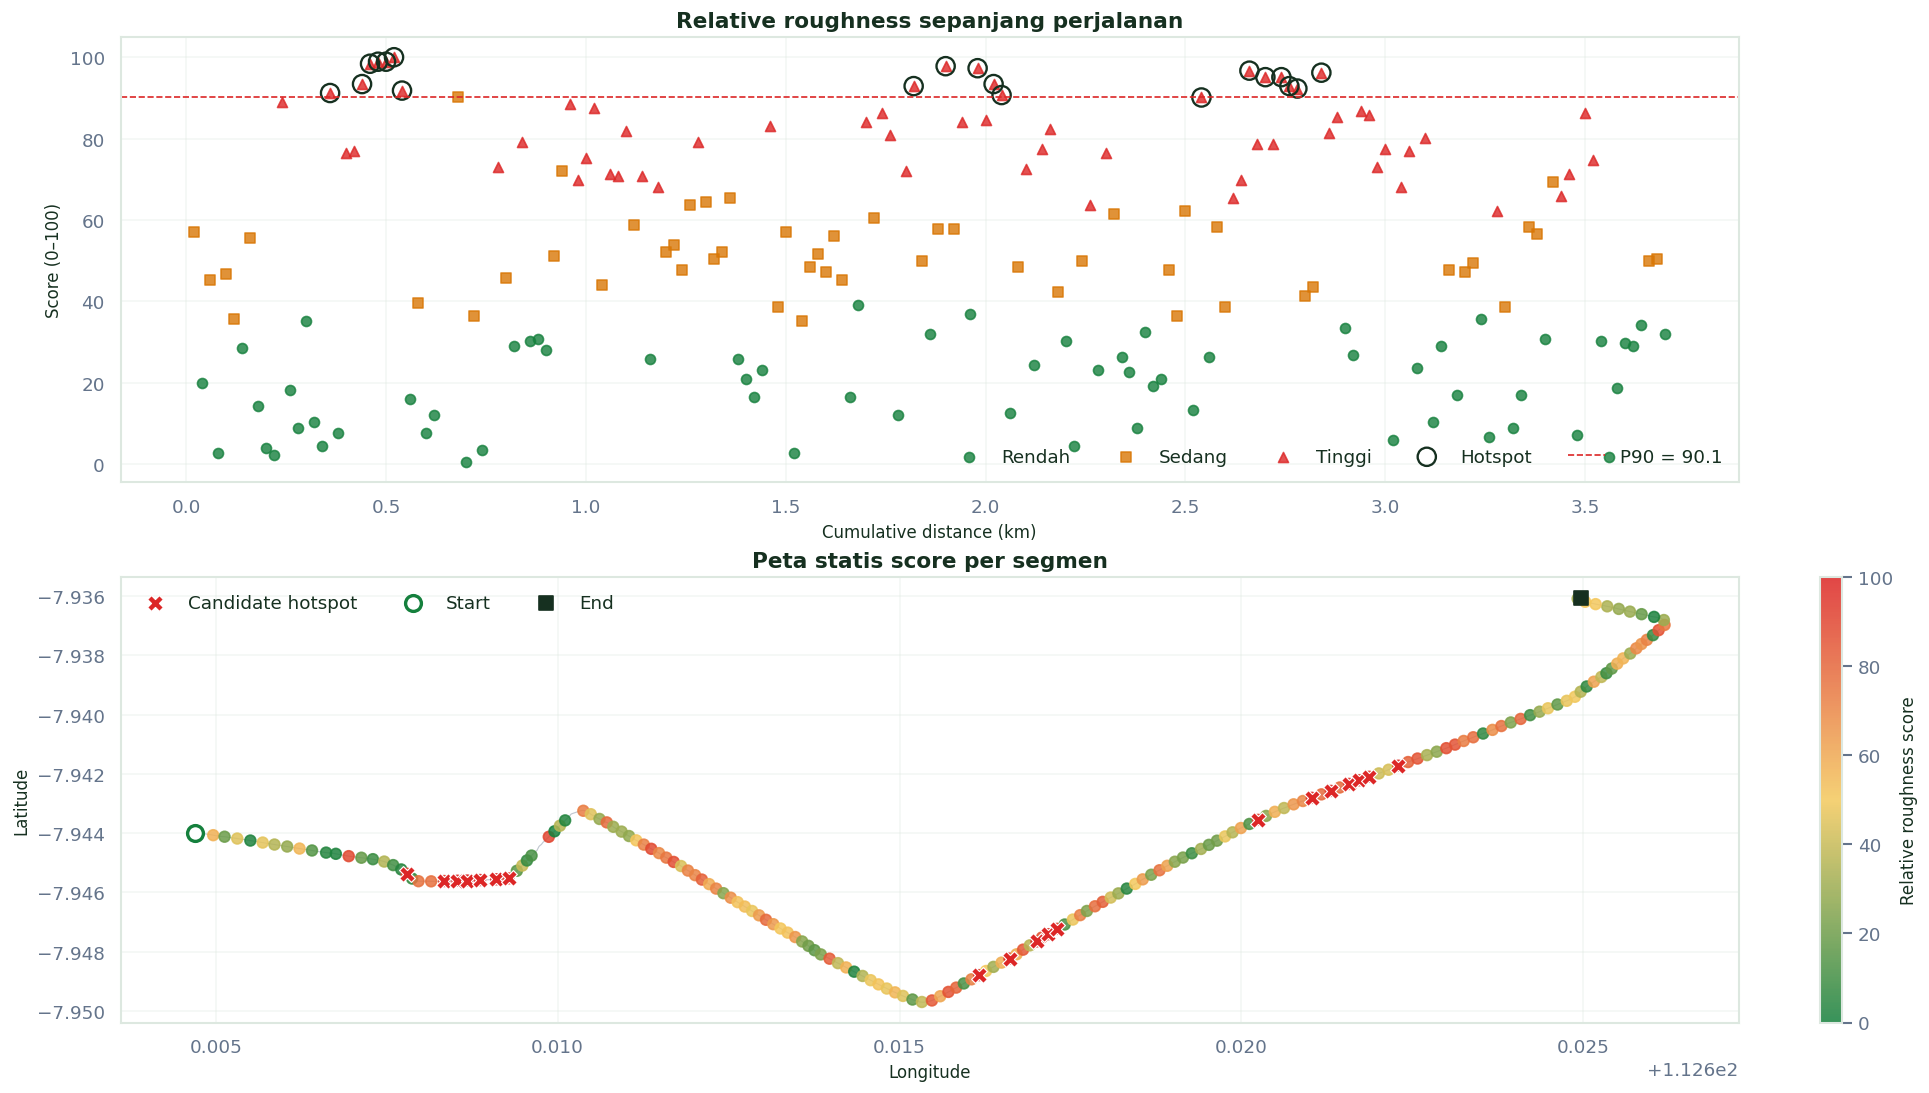

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)

# Score by traveled distance
for cls in ordered_names:
    subset = valid_results[valid_results["roughness_class"] == cls]
    axes[0].scatter(
        subset["segment_start_m"] / 1000, subset["relative_roughness_score"],
        c=CLASS_COLORS[cls], marker=CLASS_MARKERS[cls], s=36, alpha=0.8, label=cls,
    )
hotspots = valid_results[valid_results["hotspot_flag"]]
axes[0].scatter(hotspots["segment_start_m"] / 1000, hotspots["relative_roughness_score"], facecolors="none", edgecolors=COLORS["ink"], s=120, linewidths=1.4, label="Hotspot")
axes[0].axhline(hotspot_threshold, color=COLORS["danger"], ls="--", lw=1, label=f"P90 = {hotspot_threshold:.1f}")
axes[0].set(title="Relative roughness sepanjang perjalanan", xlabel="Cumulative distance (km)", ylabel="Score (0–100)")
axes[0].legend(frameon=False, ncol=5)

# Static map with explicit start/end and hotspot symbols.
route = axes[1].scatter(valid_results["longitude"], valid_results["latitude"], c=valid_results["relative_roughness_score"], cmap=ROUGHNESS_CMAP, vmin=0, vmax=100, s=42, alpha=0.85)
axes[1].plot(gps_sorted["longitude"], gps_sorted["latitude"], color=COLORS["muted"], lw=0.7, alpha=0.4, zorder=0)
axes[1].scatter(hotspots["longitude"], hotspots["latitude"], marker="X", s=90, color=COLORS["danger"], edgecolor="white", linewidth=0.7, label="Candidate hotspot")
axes[1].scatter(gps_sorted["longitude"].iloc[0], gps_sorted["latitude"].iloc[0], marker="o", s=90, facecolor="white", edgecolor=COLORS["primary"], linewidth=2, label="Start")
axes[1].scatter(gps_sorted["longitude"].iloc[-1], gps_sorted["latitude"].iloc[-1], marker="s", s=75, color=COLORS["ink"], label="End")
axes[1].set(title="Peta statis score per segmen", xlabel="Longitude", ylabel="Latitude")
axes[1].legend(frameon=False, ncol=4)
plt.colorbar(route, ax=axes[1], label="Relative roughness score")
plt.show()


In [ ]:
# Interactive map: each marker also carries text, so meaning does not rely on color alone.
map_center = [float(valid_results["latitude"].mean()), float(valid_results["longitude"].mean())]
roughness_map = folium.Map(location=map_center, zoom_start=14, tiles="CartoDB positron", control_scale=True)
folium.PolyLine(
    gps_sorted[["latitude", "longitude"]].values.tolist(),
    color="#64748B", weight=2, opacity=0.55, tooltip="GPS trajectory",
).add_to(roughness_map)

for row in valid_results.itertuples(index=False):
    cls = row.roughness_class
    radius = 7 if row.hotspot_flag else 4
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=radius,
        color=CLASS_COLORS[cls],
        fill=True,
        fill_color=CLASS_COLORS[cls],
        fill_opacity=0.88,
        weight=2 if row.hotspot_flag else 1,
        tooltip=f"Segmen {row.segment_id} · {cls} · score {row.relative_roughness_score:.1f}",
        popup=folium.Popup(
            f"<b>Segmen {row.segment_id}</b><br>Jarak: {row.segment_start_m:.0f}–{row.segment_end_m:.0f} m"
            f"<br>Score: {row.relative_roughness_score:.1f}<br>Kelas: {cls}"
            f"<br>Mean speed: {row.mean_speed_kmh:.1f} km/h<br>Hotspot: {'Ya' if row.hotspot_flag else 'Tidak'}",
            max_width=280,
        ),
    ).add_to(roughness_map)

legend = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;border:1px solid #CBD5E1;
            border-radius:8px;padding:10px 12px;font-size:12px;box-shadow:0 2px 8px rgba(0,0,0,.12)">
  <b>Relative roughness</b><br>
  <span style="color:#15803D">●</span> Rendah &nbsp;
  <span style="color:#D97706">●</span> Sedang &nbsp;
  <span style="color:#DC2626">●</span> Tinggi<br>
  Marker besar = kandidat hotspot
</div>
"""
roughness_map.get_root().html.add_child(folium.Element(legend))
display(Markdown("### Peta interaktif kandidat kekasaran"))
display(roughness_map)


### Peta interaktif kandidat kekasaran

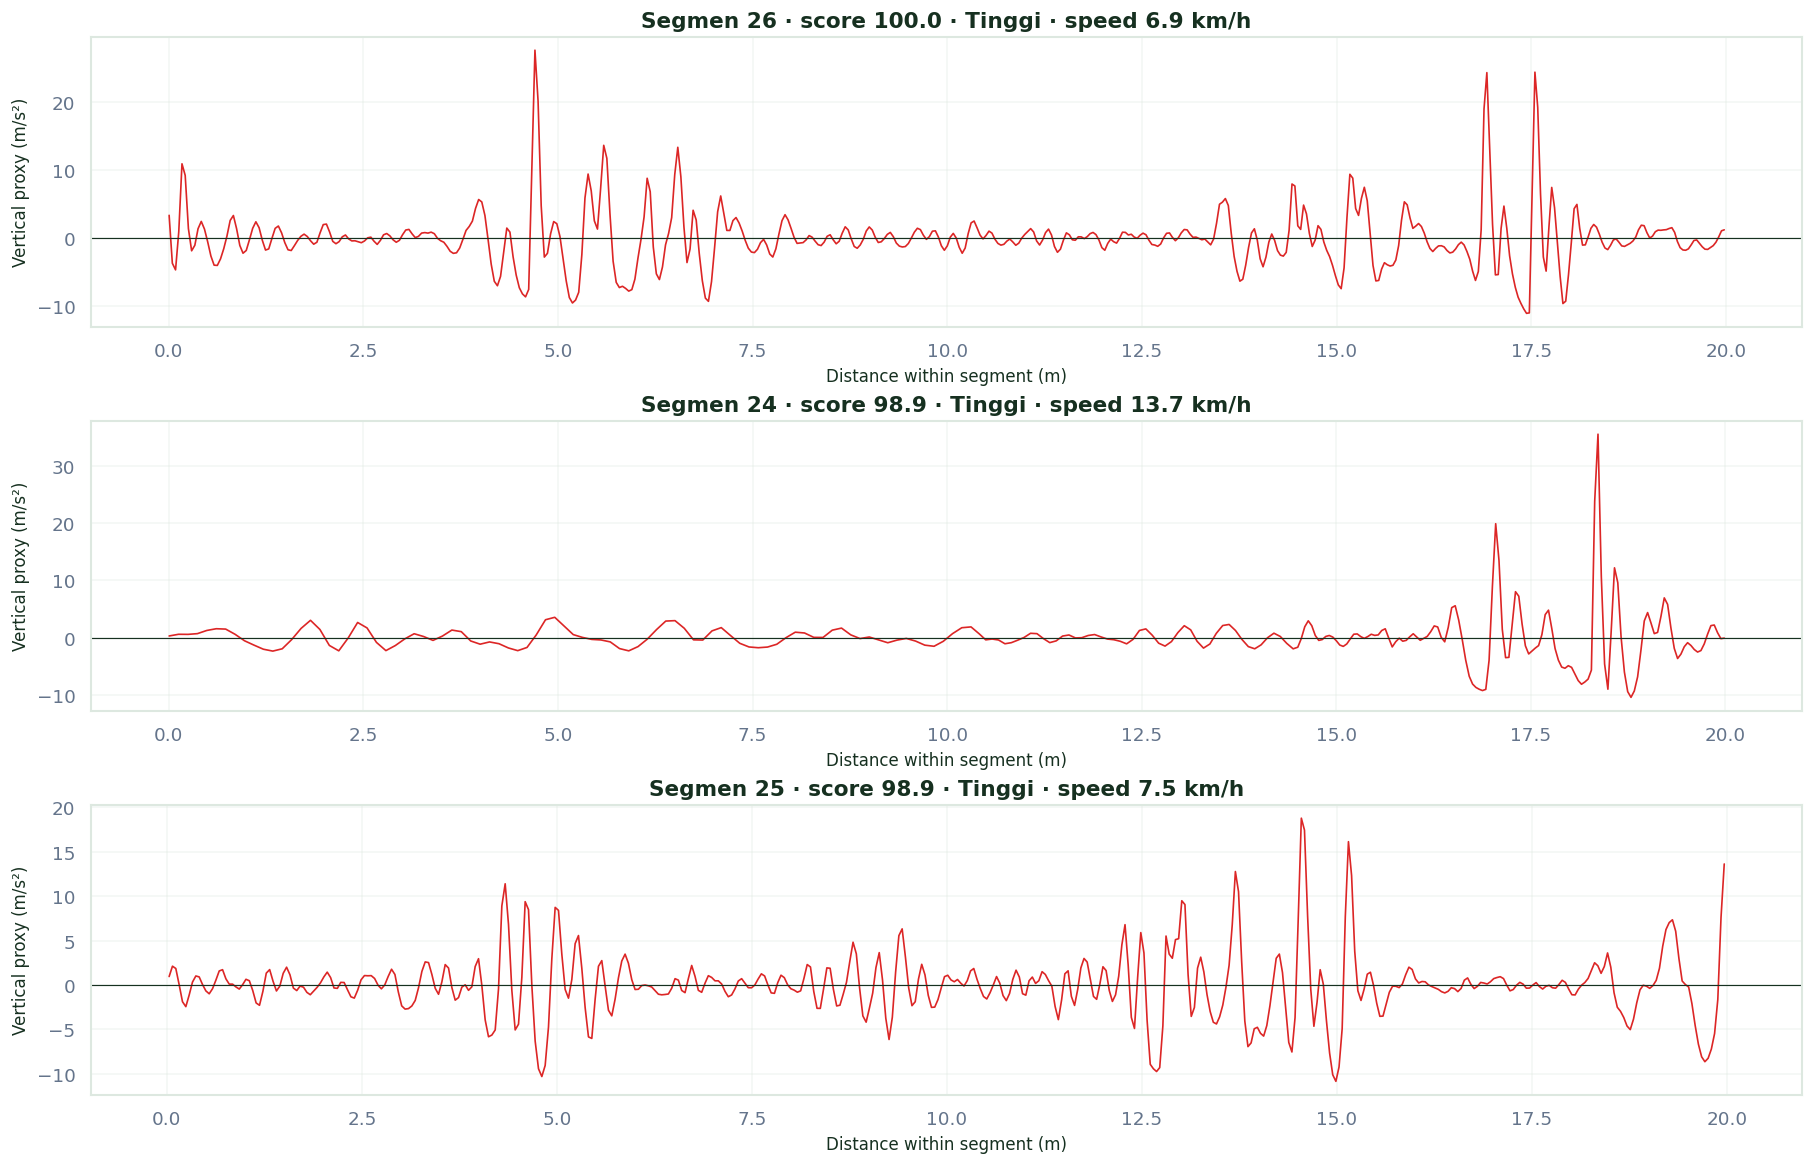

In [ ]:
# Detailed signal panels for the three highest-scoring valid segments.
representative_ids = top10["segment_id"].head(3).astype(int).tolist()
fig, axes = plt.subplots(len(representative_ids), 1, figsize=(15, 3.2 * len(representative_ids)), constrained_layout=True)
if len(representative_ids) == 1:
    axes = [axes]

for ax, segment_id in zip(axes, representative_ids):
    signal = aligned[(aligned["segment_id"] == segment_id) & aligned["analysis_valid"]].copy()
    result = valid_results.loc[valid_results["segment_id"] == segment_id].iloc[0]
    relative_distance = signal["distance_m"] - segment_id * SEGMENT_LENGTH_M
    ax.plot(relative_distance, signal["vertical_acc"], color=CLASS_COLORS[result["roughness_class"]], lw=1)
    ax.axhline(0, color=COLORS["ink"], lw=0.7)
    ax.set(
        title=f"Segmen {segment_id} · score {result['relative_roughness_score']:.1f} · {result['roughness_class']} · speed {result['mean_speed_kmh']:.1f} km/h",
        xlabel="Distance within segment (m)", ylabel="Vertical proxy (m/s²)",
    )
plt.show()


## 8 · Interpretasi, keterbatasan, dan langkah validasi berikutnya

<div class="callout success"><b>Insight yang sah.</b> Notebook berhasil meranking segmen berdasarkan pola getaran yang konsisten setelah filtering, spatial segmentation, dan speed correction. Peta membantu menentukan lokasi mana yang perlu diperiksa lebih dahulu.</div>

<div class="callout warn"><b>Jangan overclaim.</b> Getaran tinggi dapat berasal dari permukaan kasar, sambungan jalan, polisi tidur, cara mengemudi, perubahan mounting, atau dinamika sepeda. Accelerometer saja tidak dapat membedakan penyebab tersebut.</div>

### Implikasi untuk produk truk

Data saat ini adalah data **sepeda**. Transfer ke truk memerlukan kalibrasi ulang karena ban, suspensi, posisi sensor, beban, dan kecepatan mengubah respons getaran. Untuk dataset berikutnya:

- pasang perangkat secara rigid pada posisi sasis yang tetap;
- rekam `vehicle_id`, beban, tekanan ban, mounting, cuaca, dan target speed;
- lakukan minimal tiga repeated passes pada ruas yang sama dan beberapa speed bands;
- isi marker atau anotasi video untuk pothole/hump/non-damage events;
- ukur IRI/profil referensi pada segmen yang sama bila target akhirnya IRI m/km;
- gunakan split berdasarkan rute/sesi/kendaraan, bukan random split antarsegmen berdekatan.

Dengan protokol tersebut, notebook ini dapat ditingkatkan dari relative clustering menjadi supervised regression/classification yang benar-benar dapat diuji pada perjalanan baru.


In [ ]:
# -------------------------------
# ACCEPTANCE TESTS / GUARDRAILS
# -------------------------------
assertions = []

def check(name: str, condition: bool, detail: str):
    assert bool(condition), f"{name}: {detail}"
    assertions.append({"check": name, "status": "PASS", "detail": detail})

check("Required files", REQUIRED_FILES.issubset(archive_files), "Semua tujuh file tersedia")
check("No raw missing values", imu.isna().sum().sum() == 0 and gps.isna().sum().sum() == 0, "IMU dan GPS lengkap")
check("No raw duplicate rows", not imu.duplicated().any() and not gps.duplicated().any(), "Tidak ada row duplicate")
check("Per-sensor monotonic time", all(group["sensor_timestamp_ns"].is_monotonic_increasing for group in sensor_groups.values()), "Timestamp naik pada setiap sensor")
accel_hz = float(timing.loc[timing["sensor"] == "accelerometer", "effective_hz"].iloc[0])
check("Accelerometer sampling", 45 <= accel_hz <= 60, f"Effective rate {accel_hz:.2f} Hz")
check("GPS alignment", max_gps_gap <= MAX_GPS_TOLERANCE_S, f"Max gap {max_gps_gap:.3f} s")
check("Finite filtered signal", np.isfinite(aligned[["vertical_acc", "resultant_acc", "vertical_jerk"]].to_numpy()).all(), "Tidak ada NaN/inf")
check("Sufficient valid segments", len(valid_features) >= 100, f"{len(valid_features)} segmen valid")
check("Finite model matrix", np.isfinite(X).all(), "Semua model feature finite")
check("Score range", valid_features["relative_roughness_score"].between(0, 100).all(), "Semua score berada pada 0–100")
check("Three classes", set(valid_features["roughness_class"]) == set(ordered_names), "Rendah, Sedang, Tinggi tersedia")
check("Non-degenerate classes", class_counts_model.min() >= 0.05 * len(valid_features), f"Kelas terkecil {class_counts_model.min()} segmen")
class_medians = valid_features.groupby("roughness_class")["relative_roughness_score"].median().reindex(ordered_names)
check("Ordered class medians", class_medians.is_monotonic_increasing, "Median score meningkat Rendah → Sedang → Tinggi")
check("Output row coverage", len(final_table) == len(features), "Semua segmen tetap ada, termasuk yang invalid")

assertion_table = pd.DataFrame(assertions)
display(
    assertion_table.style
    .set_properties(subset=["status"], **{"color": "#15803D", "font-weight": "700"})
    .hide(axis="index")
)
display(HTML('<div class="callout success"><b>Notebook validation complete.</b> Seluruh acceptance checks lulus dan hasil siap direview.</div>'))


check,status,detail
Required files,PASS,Semua tujuh file tersedia
No raw missing values,PASS,IMU dan GPS lengkap
No raw duplicate rows,PASS,Tidak ada row duplicate
Per-sensor monotonic time,PASS,Timestamp naik pada setiap sensor
Accelerometer sampling,PASS,Effective rate 51.74 Hz
GPS alignment,PASS,Max gap 1.035 s
Finite filtered signal,PASS,Tidak ada NaN/inf
Sufficient valid segments,PASS,182 segmen valid
Finite model matrix,PASS,Semua model feature finite
Score range,PASS,Semua score berada pada 0–100


## Referensi utama

1. Zang, K., Shen, J., Huang, H., Wan, M., & Shi, J. (2018). [Assessing and Mapping of Road Surface Roughness based on GPS and Accelerometer Sensors on Bicycle-Mounted Smartphones](https://doi.org/10.3390/s18030914). *Sensors, 18*(3), 914.
2. Alessandroni, G., Carini, A., Lattanzi, E., Freschi, V., & Bogliolo, A. (2017). [A Study on the Influence of Speed on Road Roughness Sensing: The SmartRoadSense Case](https://doi.org/10.3390/s17020305). *Sensors, 17*(2), 305.
3. Islam, S., Buttlar, W. G., Aldunate, R. G., & Vavrik, W. R. (2014). [Measurement of Pavement Roughness Using Android-Based Smartphone Application](https://doi.org/10.3141/2457-04). *Transportation Research Record, 2457*(1), 30–38.
4. [SciPy Signal Processing documentation](https://docs.scipy.org/doc/scipy/reference/signal.html) — filtering, PSD, dan peak detection.
5. [Scikit-learn clustering documentation](https://scikit-learn.org/stable/modules/clustering.html) — K-Means dan internal validation.

---

**Reproducibility:** seluruh parameter, helper function, model, tabel, dan visualisasi berada di notebook ini. Random seed dikunci pada `42`; tidak ada model pickle, CSV turunan, atau modul eksternal yang diperlukan.
